# Bodrum Hotel & Destination Intelligence
## 13 - Şikayetvar All-Hotels Exploratory Data Analysis
### Negative Customer Voice — Complaint Volume, Time, Visibility, Replies and Response Behavior

Bu notebook Notebook 12'de oluşturulan canonical-unique, complaint-level matched clean corpusu
structured-field EDA ile inceler. Sentiment, topic, aspect, embedding, clustering, supervised ML
ve hotel kalite sıralaması yapılmaz.

> **Ana metodolojik uyarı:** Şikayetvar self-selected bir complaint corpusudur. Complaint count
> hotel kalitesi veya gerçek complaint rate değildir. Daha çok complaint; platform görünürlüğü,
> müşteri hacmi, marka bilinirliği ve mapping coverage ile birlikte değişebilir. Şikayetvar ve
> Google Reviews farklı kullanıcı evrenleridir. Analiz yalnız güvenilir complaint eşleşmesi bulunan
> seçili hotel örneklemini kapsar; mapping coverage 192 project hotel arasında eşit değildir.


## 01. Amaç ve metodolojik çerçeve

Araştırma soruları complaint corpusunun dağılımı, zaman kapsamı, metin uzunluğu, görüntülenme,
company response/reply davranışı ve cross-platform descriptive context üzerinedir. Hiçbir oran
gerçek müşteri complaint rate olarak adlandırılmaz. Official star, kapasite, fiyat ve Google
metrikleri yalnız coverage'ı açık keşifsel bağlam olarak kullanılır.

Hotel-level oran/medyan grafiklerinde `min_complaints_for_rate_chart=5` uygulanır. Bu eşik corpus
hotel medyanının 5 complaint olmasıyla uyumludur; düşük-n hotel'ler summary tabloda korunur ve
`small_n_flag=True` taşır.


In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import spearmanr

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.project_summary import format_number_tr, format_pct_tr, interpret_spearman
from bodrum_intelligence.sikayetvar_eda import (
    build_area_eda_summary,
    build_hotel_eda_summary,
    concentration_metrics,
    numeric_correlation_matrix,
    response_time_summary,
    spearman_table,
)

PROCESSED_DIR = PROJECT_ROOT / "data/processed"
RAW_DIR = PROJECT_ROOT / "data/raw/sikayetvar"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures/sikayetvar_eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "complaints": PROCESSED_DIR / "sikayetvar_all_hotels_complaints_clean.csv",
    "replies": PROCESSED_DIR / "sikayetvar_all_hotels_replies_clean.csv",
    "review_required": PROCESSED_DIR / "sikayetvar_complaints_review_required.csv",
    "hotel_master": PROCESSED_DIR / "hotels_enriched.csv",
    "hotel_mapping": RAW_DIR / "sikayetvar_hotel_mapping.csv",
    "cleaning_summary": REPORTS_DIR / "sikayetvar_cleaning_summary.csv",
    "clean_hotel_coverage": REPORTS_DIR / "sikayetvar_clean_coverage_by_hotel.csv",
    "clean_area_coverage": REPORTS_DIR / "sikayetvar_clean_coverage_by_area.csv",
    "scraper_consistency": REPORTS_DIR / "sikayetvar_scraper_vs_audit_consistency.csv",
    "tourism_monthly": PROCESSED_DIR / "tourism_demand_monthly_features_2025.csv",
}
missing = [str(path.relative_to(PROJECT_ROOT)) for path in paths.values() if not path.exists()]
assert not missing, f"Eksik Notebook 12 / project girdisi: {missing}"

protected_clean_paths = [paths["complaints"], paths["replies"], paths["review_required"]]
clean_hashes_before = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in protected_clean_paths}

complaints = pd.read_csv(
    paths["complaints"],
    parse_dates=["complaint_date", "company_response_date_parsed", "first_reply_date", "last_reply_date"],
)
replies = pd.read_csv(paths["replies"], parse_dates=["reply_date"])
review_required = pd.read_csv(paths["review_required"])
hotel_master = pd.read_csv(paths["hotel_master"])
hotel_mapping = pd.read_csv(paths["hotel_mapping"])
cleaning_summary = pd.read_csv(paths["cleaning_summary"]).set_index("metric")["value"]
clean_hotel_coverage = pd.read_csv(paths["clean_hotel_coverage"])
clean_area_coverage = pd.read_csv(paths["clean_area_coverage"])
scraper_consistency = pd.read_csv(paths["scraper_consistency"])
tourism_monthly = pd.read_csv(paths["tourism_monthly"])

MIN_COMPLAINTS_FOR_RATE_CHART = 5
complaints["response_time_days"] = (
    complaints["company_response_date_parsed"] - complaints["complaint_date"]
).dt.total_seconds() / 86400
complaints["response_time_negative_flag"] = complaints["response_time_days"].lt(0)
complaints.loc[complaints["response_time_negative_flag"], "response_time_days"] = np.nan

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
print(f"Clean corpus: {len(complaints)} complaint | {complaints['hotel_id'].nunique()} hotel | {complaints['area'].nunique()} area")


Clean corpus: 236 complaint | 32 hotel | 11 area


In [2]:
def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path.relative_to(PROJECT_ROOT)


def explain_figure(how_to_read, observation, importance, caution):
    display(Markdown(
        f"### Grafik nasıl okunur?\n{how_to_read}\n\n"
        f"### Ne görüyoruz?\n{observation}\n\n"
        f"### Neden önemli?\n{importance}\n\n"
        f"### Dikkat edilmesi gereken nokta\n{caution}"
    ))


## 02. Clean corpus validation

In [3]:
clean_orphan_replies = replies.loc[
    ~replies["canonical_complaint_url"].isin(set(complaints["canonical_complaint_url"]))
]
validation = pd.DataFrame([
    ("clean_complaint_row_count", int(cleaning_summary["processed_complaint_count"]), len(complaints)),
    ("unique_canonical_complaints", len(complaints), complaints["canonical_complaint_url"].nunique()),
    ("hotel_count_with_complaints", int((clean_hotel_coverage["matched_complaint_count"] > 0).sum()), complaints["hotel_id"].nunique()),
    ("area_count_represented", int((clean_area_coverage["matched_complaint_count"] > 0).sum()), complaints["area"].nunique()),
    ("duplicate_canonical_url", 0, int(complaints["canonical_complaint_url"].duplicated().sum())),
    ("missing_complaint_text", int(cleaning_summary["text_missing_count"]), int(complaints["complaint_text_clean"].isna().sum())),
    ("clean_reply_count", int(cleaning_summary["processed_reply_count"]), len(replies)),
    ("orphan_clean_reply", 0, len(clean_orphan_replies)),
], columns=["check", "notebook_12_value", "recomputed_value"])
validation["difference"] = validation["recomputed_value"] - validation["notebook_12_value"]
validation["status"] = np.where(validation["difference"].eq(0), "PASS", "WARNING")
display(validation)
assert validation["status"].eq("PASS").all(), "Notebook 12 ile clean corpus tutarsız; EDA durduruldu."
assert complaints["entity_match_status"].eq("COMPLAINT_MATCHED").all()
assert scraper_consistency["status"].eq("PASS").all()


,check,notebook_12_value,recomputed_value,difference,status
0,clean_complaint_row_count,236,236,0,PASS
1,unique_canonical_complaints,236,236,0,PASS
2,hotel_count_with_complaints,32,32,0,PASS
3,area_count_represented,11,11,0,PASS
4,duplicate_canonical_url,0,0,0,PASS
5,missing_complaint_text,7,7,0,PASS
6,clean_reply_count,97,97,0,PASS
7,orphan_clean_reply,0,0,0,PASS


In [4]:
inventory = pd.DataFrame([
    ("Clean complaints", "complaint", len(complaints), complaints["hotel_id"].nunique(), complaints["area"].nunique(), f"{complaints['complaint_date'].min():%Y-%m-%d} → {complaints['complaint_date'].max():%Y-%m-%d}", "Main EDA corpus"),
    ("Clean replies", "reply", len(replies), replies["hotel_id"].nunique(), np.nan, f"{replies['reply_date'].min():%Y-%m-%d} → {replies['reply_date'].max():%Y-%m-%d}", "Reply behavior"),
    ("Hotel master", "hotel", len(hotel_master), hotel_master["hotel_id"].nunique(), hotel_master["area"].nunique(), "2026-08-24 snapshot", "Cross-platform metadata"),
    ("Hotel mapping", "hotel mapping", len(hotel_mapping), hotel_mapping["hotel_id"].nunique(), hotel_mapping["area"].nunique(), "2026-08-25 discovery", "Coverage denominator"),
], columns=["dataset", "grain", "row_count", "unique_hotels", "unique_areas", "date_range", "main_role"])
display(inventory)


,dataset,grain,row_count,unique_hotels,unique_areas,date_range,main_role
0,Clean complaints,complaint,236,32,11.0,2023-08-28 → 2026-08-24,Main EDA corpus
1,Clean replies,reply,97,20,NaN,2024-06-28 → 2026-08-25,Reply behavior
2,Hotel master,hotel,192,192,14.0,2026-08-24 snapshot,Cross-platform metadata
3,Hotel mapping,hotel mapping,192,192,14.0,2026-08-25 discovery,Coverage denominator


### Bölüm Sonucu

Notebook 12 ile sekiz kritik KPI birebir uyumludur. Clean corpus 236 canonical-unique, complaint-level
matched kayıttan oluşur; 12 review-required kayıt bu EDA'nın dışında kalır.


## 03. Data coverage

,mapping_status,hotel_count,share_pct
0,NOT_FOUND,104,54.166667
1,REVIEW_REQUIRED,43,22.395833
2,FOUND_EXACT,31,16.145833
3,PAGE_FOUND_NO_COMPLAINT,12,6.250000
4,AMBIGUOUS,1,0.520833
5,FOUND_HIGH_CONFIDENCE,1,0.520833


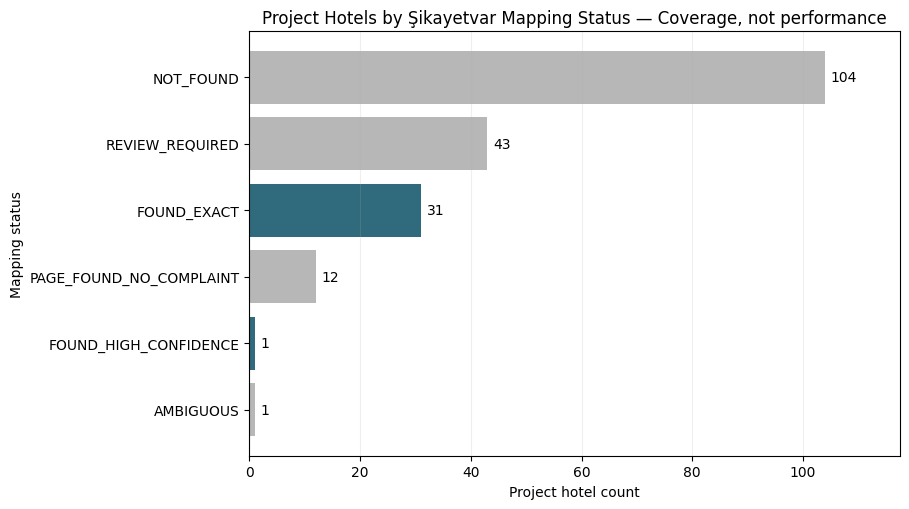

PosixPath('reports/figures/sikayetvar_eda/01_mapping_coverage_status.png')

In [5]:
mapping_status = (
    hotel_mapping["match_status"].value_counts(dropna=False)
    .rename_axis("mapping_status").reset_index(name="hotel_count")
)
mapping_status["share_pct"] = 100 * mapping_status["hotel_count"] / len(hotel_mapping)
display(mapping_status)

fig, ax = plt.subplots(figsize=(9.2, 5.2))
mapping_plot = mapping_status.sort_values("hotel_count")
colors = ["#2F6B7C" if status in {"FOUND_EXACT", "FOUND_HIGH_CONFIDENCE"} else "#B7B7B7" for status in mapping_plot["mapping_status"]]
ax.barh(mapping_plot["mapping_status"], mapping_plot["hotel_count"], color=colors)
for index, value in enumerate(mapping_plot["hotel_count"]):
    ax.text(value + 1, index, str(value), va="center")
ax.set(title="Project Hotels by Şikayetvar Mapping Status — Coverage, not performance", xlabel="Project hotel count", ylabel="Mapping status")
ax.set_xlim(0, mapping_plot["hotel_count"].max() * 1.13); ax.grid(axis="x", alpha=0.2)
save_fig(fig, "01_mapping_coverage_status.png")


In [6]:
explain_figure(
    "Her çubuk 192 project hotelin discovery/mapping statüsündeki sayısını gösterir; renkli çubuklar güvenilir hotel-level mapping statüleridir.",
    f"Clean complaint corpusu {complaints['hotel_id'].nunique()} hotel içerirken project master {len(hotel_master)} hotel içeriyor.",
    "Hotel ve area karşılaştırmalarının seçilmiş/heterojen bir coverage evreninden geldiğini gösterir.",
    "NOT_FOUND, hiç complaint olmadığı anlamına gelmez; PAGE_FOUND_NO_COMPLAINT ile de aynı değildir. Bu grafik performans grafiği değildir."
)


### Grafik nasıl okunur?
Her çubuk 192 project hotelin discovery/mapping statüsündeki sayısını gösterir; renkli çubuklar güvenilir hotel-level mapping statüleridir.

### Ne görüyoruz?
Clean complaint corpusu 32 hotel içerirken project master 192 hotel içeriyor.

### Neden önemli?
Hotel ve area karşılaştırmalarının seçilmiş/heterojen bir coverage evreninden geldiğini gösterir.

### Dikkat edilmesi gereken nokta
NOT_FOUND, hiç complaint olmadığı anlamına gelmez; PAGE_FOUND_NO_COMPLAINT ile de aynı değildir. Bu grafik performans grafiği değildir.

## 04. Complaint volume by hotel

In [7]:
hotel_summary, google_review_denominator_threshold = build_hotel_eda_summary(
    complaints, min_complaints_for_rate=MIN_COMPLAINTS_FOR_RATE_CHART, denominator_quantile=0.25
)
assert hotel_summary["matched_complaint_count"].sum() == len(complaints)
hotel_summary.insert(0, "rank_in_corpus", np.arange(1, len(hotel_summary) + 1))
display(hotel_summary.head(10)[[
    "rank_in_corpus", "hotel_name", "area", "matched_complaint_count", "share_of_corpus_pct",
    "google_review_count", "google_rating", "company_response_count", "company_response_rate_in_corpus",
]])


,rank_in_corpus,hotel_name,area,matched_complaint_count,share_of_corpus_pct,google_review_count,google_rating,company_response_count,company_response_rate_in_corpus
0,1,Kefaluka Resort,Akyarlar,29,12.288136,4293,4.4,22,75.862069
1,2,Azure By Yelken Hotel,Kadıkalesi,26,11.016949,565,4.4,1,3.846154
2,3,Yasmin Bodrum Resort,Kadıkalesi,23,9.745763,5589,4.3,0,0.000000
3,4,La Blanche Island Bodrum,Güvercinlik,19,8.050847,6594,4.3,5,26.315789
4,5,Petunya Beach Resort,Ortakent-Yahşi,13,5.508475,2687,3.7,0,0.000000
5,6,Bendis Beach Hotel,Akyarlar,12,5.084746,2469,3.9,5,41.666667
6,7,La Blanche Resort Bodrum,Turgutreis,12,5.084746,5754,4.6,0,0.000000
7,8,Green Bay Resort & Spa Bodrum,Güvercinlik,11,4.661017,6843,4.5,0,0.000000
8,9,The Oba Hotel,Torba,10,4.237288,603,4.0,0,0.000000
9,10,Selectum Colours Bodrum,Gümbet,8,3.389831,13412,4.8,0,0.000000


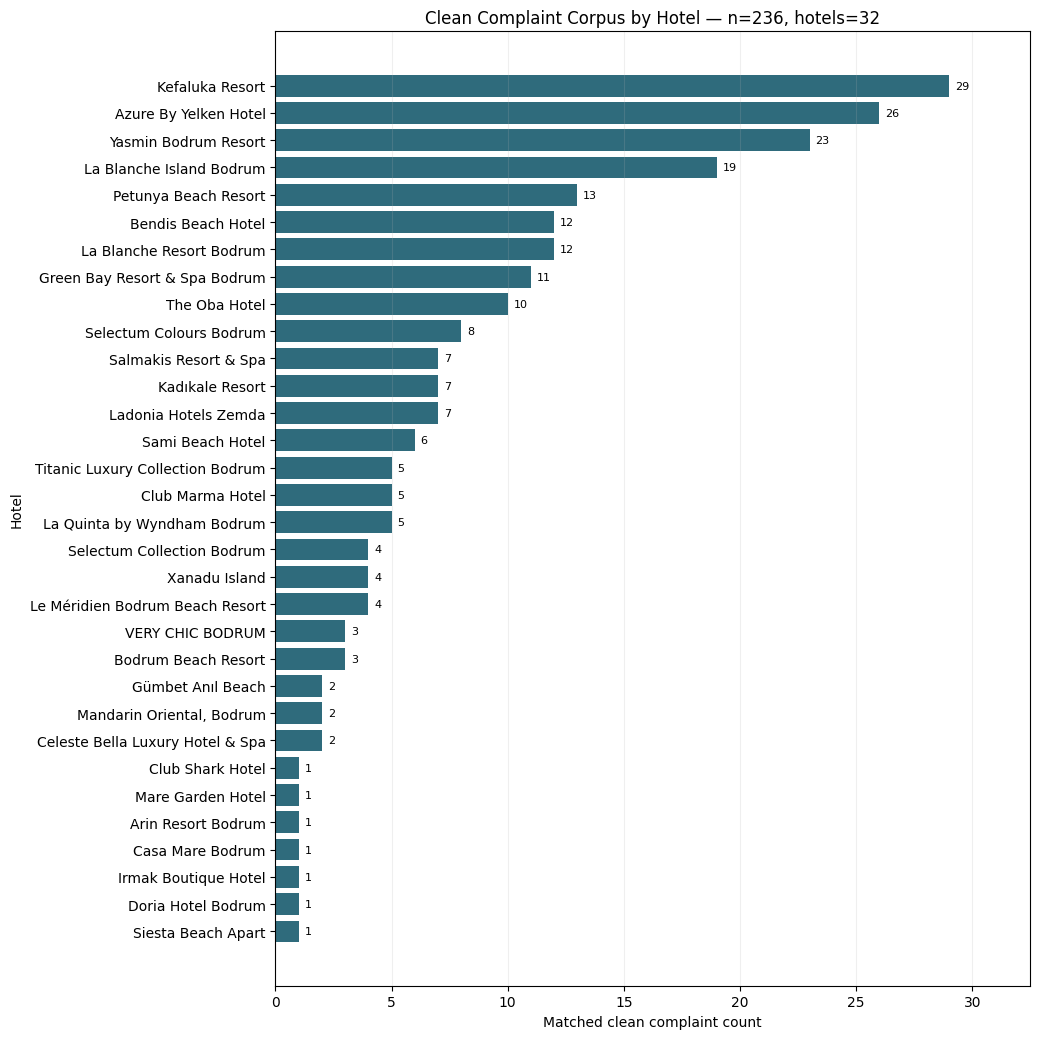

PosixPath('reports/figures/sikayetvar_eda/02_complaint_count_by_hotel.png')

In [8]:
hotel_plot = hotel_summary.sort_values("matched_complaint_count")
fig, ax = plt.subplots(figsize=(10.5, 10.5))
ax.barh(hotel_plot["hotel_name"], hotel_plot["matched_complaint_count"], color="#2F6B7C")
for index, value in enumerate(hotel_plot["matched_complaint_count"]):
    ax.text(value + 0.25, index, str(value), va="center", fontsize=8)
ax.set(title=f"Clean Complaint Corpus by Hotel — n={len(complaints)}, hotels={len(hotel_summary)}", xlabel="Matched clean complaint count", ylabel="Hotel")
ax.set_xlim(0, hotel_plot["matched_complaint_count"].max() * 1.12); ax.grid(axis="x", alpha=0.2)
save_fig(fig, "02_complaint_count_by_hotel.png")


In [9]:
top_hotel = hotel_summary.iloc[0]
explain_figure(
    "Her çubuk clean corpusta bir hotele bağlanan canonical-unique complaint sayısını gösterir.",
    f"En yüksek corpus hacmi {top_hotel['hotel_name']} için {int(top_hotel['matched_complaint_count'])} kayıttır; toplam {len(hotel_summary)} hotel temsil edilir.",
    "Corpusun hotel düzeyinde ne kadar dengesiz dağıldığını ve hangi gruplarda EDA/NLP sample'ının daha büyük olduğunu gösterir.",
    "Bu sayı hotel kalitesi, gerçek müşteri complaint rate veya 'en kötü hotel' sıralaması değildir. Platform görünürlüğü ve müşteri hacmi bilinmiyor."
)


### Grafik nasıl okunur?
Her çubuk clean corpusta bir hotele bağlanan canonical-unique complaint sayısını gösterir.

### Ne görüyoruz?
En yüksek corpus hacmi Kefaluka Resort için 29 kayıttır; toplam 32 hotel temsil edilir.

### Neden önemli?
Corpusun hotel düzeyinde ne kadar dengesiz dağıldığını ve hangi gruplarda EDA/NLP sample'ının daha büyük olduğunu gösterir.

### Dikkat edilmesi gereken nokta
Bu sayı hotel kalitesi, gerçek müşteri complaint rate veya 'en kötü hotel' sıralaması değildir. Platform görünürlüğü ve müşteri hacmi bilinmiyor.

## 05. Complaint concentration

,metric,value
0,top3_hotel_complaint_share_pct,33.050847
1,top5_hotel_complaint_share_pct,46.610169
2,top10_hotel_complaint_share_pct,69.067797
3,hotels_to_reach_80pct,14.000000
4,hhi_hotel_complaint_concentration,0.062698


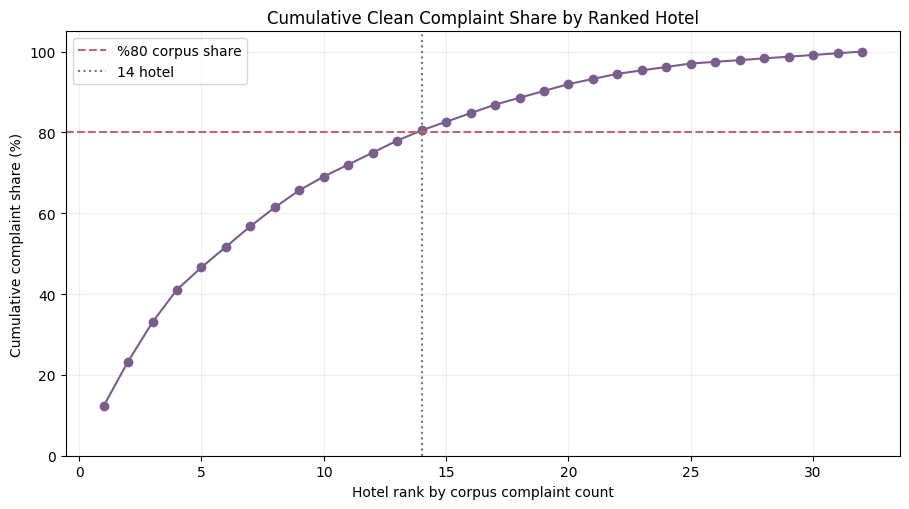

PosixPath('reports/figures/sikayetvar_eda/03_complaint_concentration.png')

In [10]:
concentration = concentration_metrics(hotel_summary)
concentration_table = pd.DataFrame({"metric": list(concentration), "value": list(concentration.values())})
display(concentration_table)

ranked = hotel_summary.sort_values("matched_complaint_count", ascending=False).copy()
ranked["hotel_rank"] = np.arange(1, len(ranked) + 1)
ranked["cumulative_complaint_share_pct"] = 100 * ranked["matched_complaint_count"].cumsum() / len(complaints)
fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.plot(ranked["hotel_rank"], ranked["cumulative_complaint_share_pct"], marker="o", color="#7A5C8E")
ax.axhline(80, linestyle="--", color="#C1666B", label="%80 corpus share")
ax.axvline(concentration["hotels_to_reach_80pct"], linestyle=":", color="#777777", label=f"{concentration['hotels_to_reach_80pct']} hotel")
ax.set(title="Cumulative Clean Complaint Share by Ranked Hotel", xlabel="Hotel rank by corpus complaint count", ylabel="Cumulative complaint share (%)", ylim=(0, 105))
ax.grid(alpha=0.2); ax.legend()
save_fig(fig, "03_complaint_concentration.png")


In [11]:
explain_figure(
    "Hotel'ler corpus complaint sayısına göre sıralanır; çizgi ilk N hotelin toplam corpus payını gösterir.",
    f"Top-5 hotel corpusun {format_pct_tr(concentration['top5_hotel_complaint_share_pct'])}'ini taşır; %80 paya {int(concentration['hotels_to_reach_80pct'])} hotelde ulaşılır.",
    "NLP ve hotel-level karşılaştırmalarda sample büyüklüğünün az sayıda hotelde yoğunlaştığını gösterir.",
    "Concentration kalite sorunu değildir; yalnız scraped/mapped corpus dağılımıdır."
)


### Grafik nasıl okunur?
Hotel'ler corpus complaint sayısına göre sıralanır; çizgi ilk N hotelin toplam corpus payını gösterir.

### Ne görüyoruz?
Top-5 hotel corpusun %46,6'ini taşır; %80 paya 14 hotelde ulaşılır.

### Neden önemli?
NLP ve hotel-level karşılaştırmalarda sample büyüklüğünün az sayıda hotelde yoğunlaştığını gösterir.

### Dikkat edilmesi gereken nokta
Concentration kalite sorunu değildir; yalnız scraped/mapped corpus dağılımıdır.

## 06. Complaint distribution by area

In [12]:
area_summary = build_area_eda_summary(complaints, hotel_mapping, hotel_master)
assert int(area_summary["matched_complaint_count"].sum()) == len(complaints)
area_summary["small_n_flag"] = area_summary["matched_complaint_count"].lt(MIN_COMPLAINTS_FOR_RATE_CHART)
display(area_summary[[
    "area", "project_hotel_count", "mapped_hotel_count", "hotels_with_complaints",
    "mapping_coverage_pct", "matched_complaint_count", "complaint_share_pct", "small_n_flag",
]])


,area,project_hotel_count,mapped_hotel_count,hotels_with_complaints,mapping_coverage_pct,matched_complaint_count,complaint_share_pct,small_n_flag
0,Kadıkalesi,4,3,3,75.000000,56,23.728814,False
1,Akyarlar,16,5,6,31.250000,55,23.305085,False
2,Güvercinlik,10,5,4,50.000000,39,16.525424,False
3,Gümbet,15,6,7,40.000000,24,10.169492,False
4,Ortakent-Yahşi,21,3,3,14.285714,16,6.779661,False
5,Bodrum Merkez,13,3,3,23.076923,13,5.508475,False
6,Turgutreis,7,2,2,28.571429,13,5.508475,False
7,Torba,21,1,1,4.761905,10,4.237288,False
8,Gümüşlük,15,1,1,6.666667,7,2.966102,False
9,Göltürkbükü,10,1,1,10.000000,2,0.847458,True


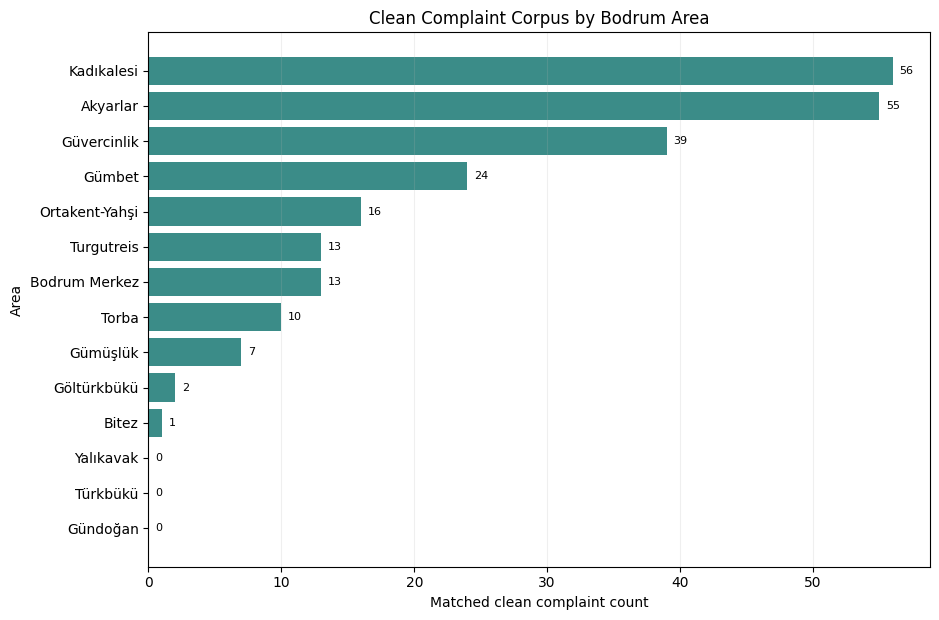

PosixPath('reports/figures/sikayetvar_eda/04_complaints_by_area.png')

In [13]:
area_plot = area_summary.sort_values("matched_complaint_count")
fig, ax = plt.subplots(figsize=(9.5, 6.3))
ax.barh(area_plot["area"], area_plot["matched_complaint_count"], color="#3B8C88")
for index, value in enumerate(area_plot["matched_complaint_count"]):
    ax.text(value + 0.5, index, str(int(value)), va="center", fontsize=8)
ax.set(title="Clean Complaint Corpus by Bodrum Area", xlabel="Matched clean complaint count", ylabel="Area")
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "04_complaints_by_area.png")


In [14]:
top_area = area_summary.iloc[0]
explain_figure(
    "Area çubukları, hotel-level clean complaint sayılarını lokasyon bazında toplar.",
    f"En büyük corpus hacmi {top_area['area']} alanında {int(top_area['matched_complaint_count'])} complaint'tir.",
    "Destination içindeki corpus dağılımını, hotel sayısı ve mapping coverage ile birlikte okumayı sağlar.",
    "Area toplamları gerçek turizm talebi veya gerçek complaint rate değildir; alanlardaki hotel ve mapping coverage farklıdır."
)


### Grafik nasıl okunur?
Area çubukları, hotel-level clean complaint sayılarını lokasyon bazında toplar.

### Ne görüyoruz?
En büyük corpus hacmi Kadıkalesi alanında 56 complaint'tir.

### Neden önemli?
Destination içindeki corpus dağılımını, hotel sayısı ve mapping coverage ile birlikte okumayı sağlar.

### Dikkat edilmesi gereken nokta
Area toplamları gerçek turizm talebi veya gerçek complaint rate değildir; alanlardaki hotel ve mapping coverage farklıdır.

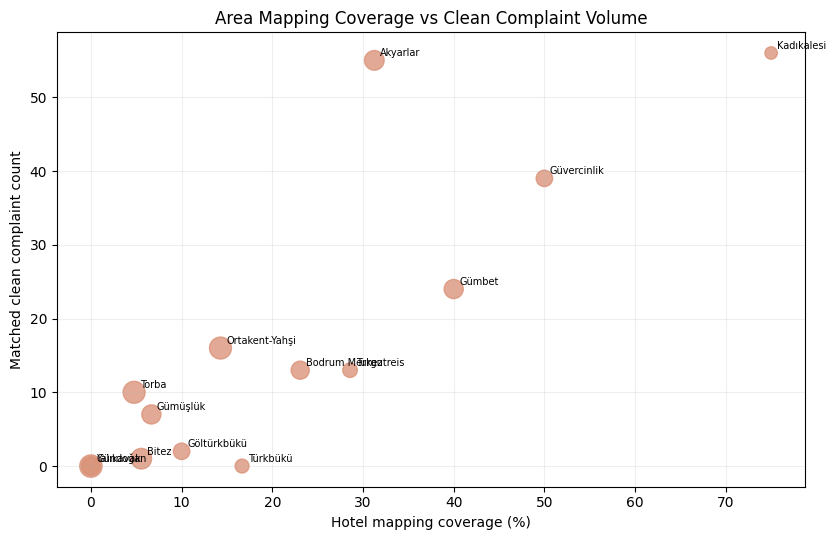

PosixPath('reports/figures/sikayetvar_eda/05_area_coverage_vs_complaints.png')

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sizes = 40 + 10 * area_summary["project_hotel_count"]
ax.scatter(area_summary["mapping_coverage_pct"], area_summary["matched_complaint_count"], s=sizes, alpha=0.75, color="#D98E73")
for _, row in area_summary.iterrows():
    ax.annotate(row["area"], (row["mapping_coverage_pct"], row["matched_complaint_count"]), xytext=(4, 3), textcoords="offset points", fontsize=7)
ax.set(title="Area Mapping Coverage vs Clean Complaint Volume", xlabel="Hotel mapping coverage (%)", ylabel="Matched clean complaint count")
ax.grid(alpha=0.2)
save_fig(fig, "05_area_coverage_vs_complaints.png")


In [16]:
area_cov_corr = stats.spearmanr(area_summary["mapping_coverage_pct"], area_summary["matched_complaint_count"], nan_policy="omit")
explain_figure(
    "Her nokta bir area; x ekseni project hotel master içindeki mapping coverage, y ekseni clean complaint sayısıdır. Nokta boyutu project hotel sayısını gösterir.",
    f"Area-level Spearman ilişki rho={area_cov_corr.statistic:.3f}; n={len(area_summary)}. Sıfır complaint'li alanlar da grafiktedir.",
    "Yüksek/düşük area hacminin coverage ile birlikte değerlendirilmesi gerektiğini gösterir.",
    "Yalnız 14 area vardır; ilişki nedensel değildir ve platform erişilebilirliği ile hotel karması sonucu etkiler."
)


### Grafik nasıl okunur?
Her nokta bir area; x ekseni project hotel master içindeki mapping coverage, y ekseni clean complaint sayısıdır. Nokta boyutu project hotel sayısını gösterir.

### Ne görüyoruz?
Area-level Spearman ilişki rho=0.841; n=14. Sıfır complaint'li alanlar da grafiktedir.

### Neden önemli?
Yüksek/düşük area hacminin coverage ile birlikte değerlendirilmesi gerektiğini gösterir.

### Dikkat edilmesi gereken nokta
Yalnız 14 area vardır; ilişki nedensel değildir ve platform erişilebilirliği ile hotel karması sonucu etkiler.

## 07. Cross-platform visibility context

`cross_platform_complaint_visibility_per_1000_google_reviews` gerçek bir complaint rate değildir. Numeratör Şikayetvar'daki
clean mapped corpus; denominator Google'daki all-time review count'tur. Dönem, kullanıcı tabanı ve
platform davranışı aynı değildir. Bu nedenle metrik yalnız **cross-platform visibility index** olarak
yorumlanır.


In [17]:
cross_platform_summary = hotel_summary[[
    "hotel_name", "area", "matched_complaint_count", "google_review_count", "google_rating",
    "cross_platform_complaint_visibility_per_1000_google_reviews", "low_google_review_denominator_flag", "small_n_flag",
]].copy()
cross_platform_summary["interpretation_caution"] = "Visibility index; not a real complaint rate"
display(cross_platform_summary.sort_values("cross_platform_complaint_visibility_per_1000_google_reviews", ascending=False).head(10))
print("Lowest-quartile Google review denominator threshold:", google_review_denominator_threshold)


,hotel_name,area,matched_complaint_count,google_review_count,google_rating,cross_platform_complaint_visibility_per_1000_google_reviews,low_google_review_denominator_flag,small_n_flag,interpretation_caution
1,Azure By Yelken Hotel,Kadıkalesi,26,565,4.4,46.017699,True,False,Visibility index; not a real complaint rate
12,Ladonia Hotels Zemda,Gümüşlük,7,376,3.8,18.617021,True,False,Visibility index; not a real complaint rate
8,The Oba Hotel,Torba,10,603,4.0,16.583748,True,False,Visibility index; not a real complaint rate
24,Celeste Bella Luxury Hotel & Spa,Ortakent-Yahşi,2,258,4.3,7.751938,True,True,Visibility index; not a real complaint rate
0,Kefaluka Resort,Akyarlar,29,4293,4.4,6.755183,False,False,Visibility index; not a real complaint rate
5,Bendis Beach Hotel,Akyarlar,12,2469,3.9,4.860267,False,False,Visibility index; not a real complaint rate
4,Petunya Beach Resort,Ortakent-Yahşi,13,2687,3.7,4.838109,False,False,Visibility index; not a real complaint rate
19,Le Méridien Bodrum Beach Resort,Güvercinlik,4,848,4.2,4.716981,False,True,Visibility index; not a real complaint rate
2,Yasmin Bodrum Resort,Kadıkalesi,23,5589,4.3,4.115226,False,False,Visibility index; not a real complaint rate
28,Irmak Boutique Hotel,Ortakent-Yahşi,1,262,4.6,3.816794,True,True,Visibility index; not a real complaint rate


Lowest-quartile Google review denominator threshold: 731.25


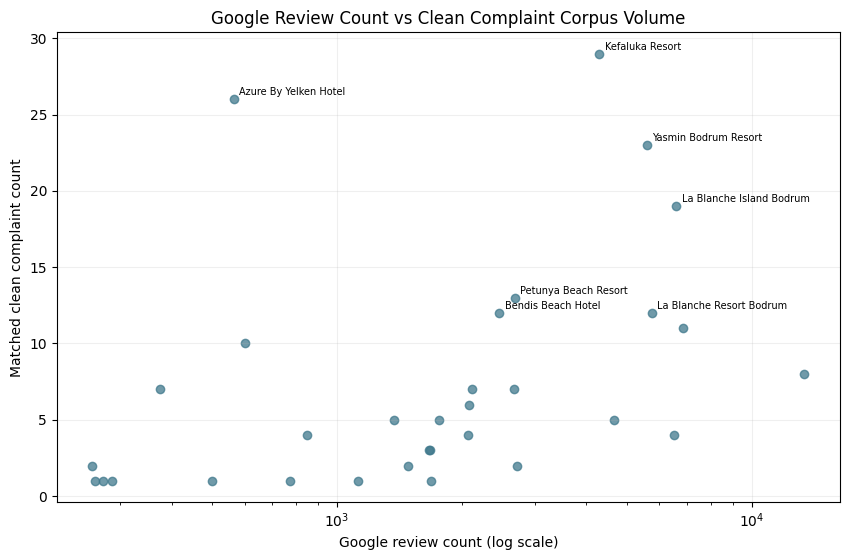

PosixPath('reports/figures/sikayetvar_eda/06_google_reviews_vs_complaints.png')

In [18]:
google_pair = hotel_summary.dropna(subset=["google_review_count", "matched_complaint_count"])
google_corr = stats.spearmanr(google_pair["google_review_count"], google_pair["matched_complaint_count"])
fig, ax = plt.subplots(figsize=(8.6, 5.7))
ax.scatter(google_pair["google_review_count"], google_pair["matched_complaint_count"], alpha=0.75, color="#40798C")
for _, row in google_pair.nlargest(7, "matched_complaint_count").iterrows():
    ax.annotate(row["hotel_name"], (row["google_review_count"], row["matched_complaint_count"]), xytext=(4, 3), textcoords="offset points", fontsize=7)
ax.set_xscale("log")
ax.set(title="Google Review Count vs Clean Complaint Corpus Volume", xlabel="Google review count (log scale)", ylabel="Matched clean complaint count")
ax.grid(alpha=0.2)
save_fig(fig, "06_google_reviews_vs_complaints.png")


In [19]:
explain_figure(
    "Her nokta bir hotel; Google review count genel online görünürlüğe bağlam, clean complaint count ise bu projenin Şikayetvar corpus hacmini verir.",
    f"Spearman rho={google_corr.statistic:.3f}, p={google_corr.pvalue:.4f}, n={len(google_pair)}; daha görünür hotel'lerde corpus hacmi de çoğunlukla daha yüksektir.",
    "Ham complaint count karşılaştırmalarında exposure/visibility bağlamının neden gerekli olduğunu gösterir.",
    "Platformlar, zaman pencereleri ve kullanıcı davranışı farklıdır; Google review count müşteri sayısı değildir."
)


### Grafik nasıl okunur?
Her nokta bir hotel; Google review count genel online görünürlüğe bağlam, clean complaint count ise bu projenin Şikayetvar corpus hacmini verir.

### Ne görüyoruz?
Spearman rho=0.587, p=0.0004, n=32; daha görünür hotel'lerde corpus hacmi de çoğunlukla daha yüksektir.

### Neden önemli?
Ham complaint count karşılaştırmalarında exposure/visibility bağlamının neden gerekli olduğunu gösterir.

### Dikkat edilmesi gereken nokta
Platformlar, zaman pencereleri ve kullanıcı davranışı farklıdır; Google review count müşteri sayısı değildir.

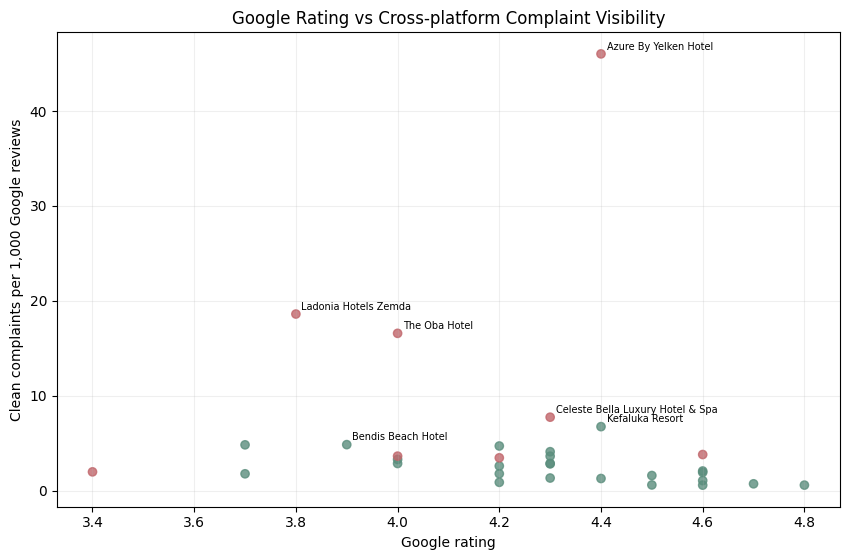

PosixPath('reports/figures/sikayetvar_eda/07_visibility_vs_google_rating.png')

In [20]:
visibility_pair = hotel_summary.dropna(subset=["google_rating", "cross_platform_complaint_visibility_per_1000_google_reviews"])
visibility_corr = stats.spearmanr(visibility_pair["google_rating"], visibility_pair["cross_platform_complaint_visibility_per_1000_google_reviews"])
colors = np.where(visibility_pair["low_google_review_denominator_flag"], "#C1666B", "#5B8E7D")
fig, ax = plt.subplots(figsize=(8.6, 5.7))
ax.scatter(visibility_pair["google_rating"], visibility_pair["cross_platform_complaint_visibility_per_1000_google_reviews"], c=colors, alpha=0.8)
for _, row in visibility_pair.nlargest(6, "cross_platform_complaint_visibility_per_1000_google_reviews").iterrows():
    ax.annotate(row["hotel_name"], (row["google_rating"], row["cross_platform_complaint_visibility_per_1000_google_reviews"]), xytext=(4, 3), textcoords="offset points", fontsize=7)
ax.set(title="Google Rating vs Cross-platform Complaint Visibility", xlabel="Google rating", ylabel="Clean complaints per 1,000 Google reviews")
ax.grid(alpha=0.2)
save_fig(fig, "07_visibility_vs_google_rating.png")


In [21]:
explain_figure(
    "Her nokta bir hotel; kırmızı noktalar Google review denominator'ı alt çeyrekte olan, daha oynak görünürlük indekslerini işaretler.",
    f"Spearman rho={visibility_corr.statistic:.3f}, p={visibility_corr.pvalue:.4f}, n={len(visibility_pair)}.",
    "Google rating ile Şikayetvar corpus görünürlüğü arasındaki yönsel ilişkiyi keşifsel olarak gösterir.",
    "Bu eksenler ortak bir memnuniyet ölçeği değildir. İndeks complaint rate değildir; düşük denominator ve küçük complaint sample'ları özellikle ihtiyat ister."
)


### Grafik nasıl okunur?
Her nokta bir hotel; kırmızı noktalar Google review denominator'ı alt çeyrekte olan, daha oynak görünürlük indekslerini işaretler.

### Ne görüyoruz?
Spearman rho=-0.452, p=0.0093, n=32.

### Neden önemli?
Google rating ile Şikayetvar corpus görünürlüğü arasındaki yönsel ilişkiyi keşifsel olarak gösterir.

### Dikkat edilmesi gereken nokta
Bu eksenler ortak bir memnuniyet ölçeği değildir. İndeks complaint rate değildir; düşük denominator ve küçük complaint sample'ları özellikle ihtiyat ister.

In [22]:
company_response_count = int(complaints["company_response_exists_clean"].fillna(False).sum())
complaints_with_replies = int(complaints["reply_count_total_derived"].gt(0).sum())
corpus_kpis = pd.DataFrame([
    ("Clean matched complaints", len(complaints), "Canonical-unique complaint-level matched"),
    ("Hotels with matched complaints", complaints["hotel_id"].nunique(), "Selected mapped-hotel sample"),
    ("Areas represented", complaints["area"].nunique(), "11/14 project area"),
    ("Company responses", company_response_count, format_pct_tr(100*company_response_count/len(complaints))),
    ("Total replies", len(replies), "COMPANY + USER + UNKNOWN"),
    ("Complaints with replies", complaints_with_replies, format_pct_tr(100*complaints_with_replies/len(complaints))),
    ("Median complaint words", complaints["complaint_word_count"].median(), "Missing text excluded"),
    ("Date coverage", int(complaints["complaint_date"].notna().sum()), format_pct_tr(100*complaints["complaint_date"].notna().mean())),
    ("View coverage", int(complaints["view_count_numeric"].notna().sum()), format_pct_tr(100*complaints["view_count_numeric"].notna().mean())),
], columns=["KPI", "Value", "Interpretation"])
display(corpus_kpis)


,KPI,Value,Interpretation
0,Clean matched complaints,236.0,Canonical-unique complaint-level matched
1,Hotels with matched complaints,32.0,Selected mapped-hotel sample
2,Areas represented,11.0,11/14 project area
3,Company responses,39.0,"%16,5"
4,Total replies,97.0,COMPANY + USER + UNKNOWN
5,Complaints with replies,62.0,"%26,3"
6,Median complaint words,144.0,Missing text excluded
7,Date coverage,226.0,"%95,8"
8,View coverage,225.0,"%95,3"


### Bölüm Sonucu

Ana EDA evreni project hotel masterının tamamı değil, complaint-level güvenilir eşleşmesi bulunan 32
hoteldir. Bu coverage sınırı tüm hotel, area ve cross-platform sonuçlarının parçasıdır.


## 08. Temporal distribution

Tarih coverage'ı ve approximate-date kayıtları sonuçla birlikte raporlanır. 2023 ve 2026 tam yıl
değildir; özellikle 2026, scrape erişilebilirliği ve yılın henüz tamamlanmaması nedeniyle trend
karşılaştırmasına uygun değildir.


In [23]:
dated = complaints.dropna(subset=["complaint_date"]).copy()
dated["year"] = dated["complaint_date"].dt.year.astype(int)
dated["month"] = dated["complaint_date"].dt.month.astype(int)
yearly = dated.groupby("year").size().rename("complaint_count").reset_index()
monthly = pd.DataFrame({"month": np.arange(1, 13)}).merge(
    dated.groupby("month").size().rename("complaint_count").reset_index(), on="month", how="left"
).fillna({"complaint_count": 0})
monthly["complaint_count"] = monthly["complaint_count"].astype(int)
monthly["month_name"] = monthly["month"].map({1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"})
temporal_summary = pd.concat([
    yearly.assign(granularity="year", period=yearly["year"].astype(str))[["granularity", "period", "complaint_count"]],
    monthly.assign(granularity="month_of_year", period=monthly["month_name"])[["granularity", "period", "complaint_count"]],
], ignore_index=True)
display(pd.DataFrame({
    "metric": ["dated_records", "date_coverage_pct", "approximate_date_count", "min_date", "max_date"],
    "value": [len(dated), 100*len(dated)/len(complaints), int(complaints["complaint_date_is_approximate"].sum()), dated["complaint_date"].min().date(), dated["complaint_date"].max().date()],
}))
display(yearly)


,metric,value
0,dated_records,226
1,date_coverage_pct,95.762712
2,approximate_date_count,86
3,min_date,2023-08-28
4,max_date,2026-08-24


,year,complaint_count
0,2023,3
1,2024,45
2,2025,92
3,2026,86


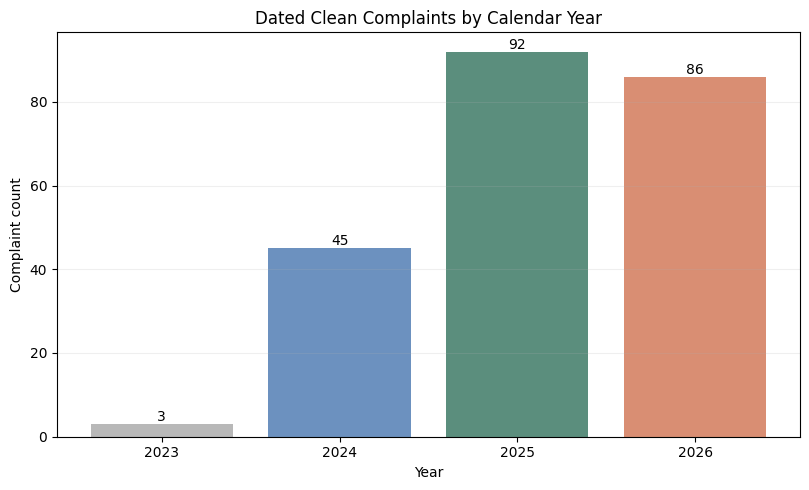

PosixPath('reports/figures/sikayetvar_eda/08_complaints_by_year.png')

In [24]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))
bars = ax.bar(yearly["year"].astype(str), yearly["complaint_count"], color=["#B8B8B8", "#6C91BF", "#5B8E7D", "#D98E73"])
ax.bar_label(bars)
ax.set(title="Dated Clean Complaints by Calendar Year", xlabel="Year", ylabel="Complaint count")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "08_complaints_by_year.png")


In [25]:
explain_figure(
    "Yalnız complaint_date parse edilen clean kayıtlar takvim yılına göre sayılır.",
    f"Date coverage {format_pct_tr(100*len(dated)/len(complaints))}; gözlenen aralık {dated['complaint_date'].min().date()}–{dated['complaint_date'].max().date()}.",
    "Corpusun hangi yıllarda yoğunlaştığını ve zaman analizinin fiili penceresini gösterir.",
    "2023 ve 2026 kısmi yıldır; scrape/mapping erişilebilirliği zaman içinde sabit değildir. Yıllar arası büyüme sonucu çıkarılamaz."
)


### Grafik nasıl okunur?
Yalnız complaint_date parse edilen clean kayıtlar takvim yılına göre sayılır.

### Ne görüyoruz?
Date coverage %95,8; gözlenen aralık 2023-08-28–2026-08-24.

### Neden önemli?
Corpusun hangi yıllarda yoğunlaştığını ve zaman analizinin fiili penceresini gösterir.

### Dikkat edilmesi gereken nokta
2023 ve 2026 kısmi yıldır; scrape/mapping erişilebilirliği zaman içinde sabit değildir. Yıllar arası büyüme sonucu çıkarılamaz.

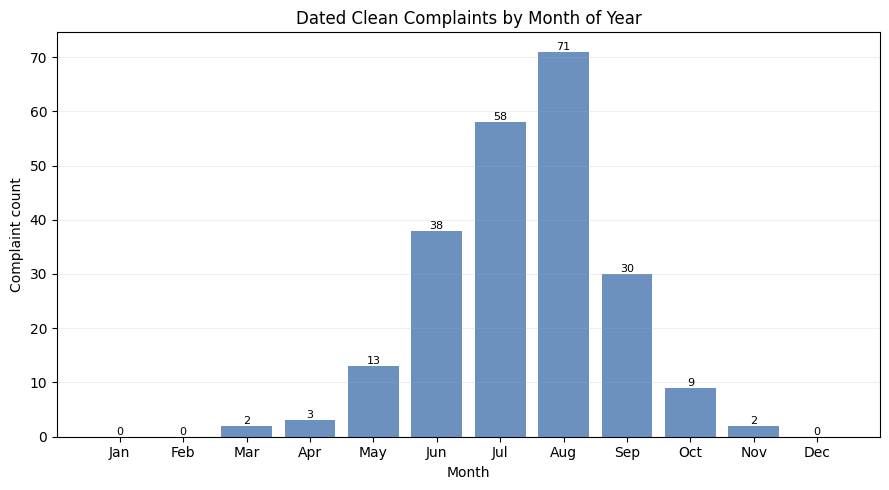

PosixPath('reports/figures/sikayetvar_eda/09_complaints_by_month.png')

In [26]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
bars = ax.bar(monthly["month_name"], monthly["complaint_count"], color="#6C91BF")
ax.bar_label(bars, fontsize=8)
ax.set(title="Dated Clean Complaints by Month of Year", xlabel="Month", ylabel="Complaint count")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "09_complaints_by_month.png")


In [27]:
peak_month = monthly.loc[monthly["complaint_count"].idxmax()]
explain_figure(
    "Tüm yıllardaki dated complaints takvim ayına göre birleştirilir; sıfır gözlenen aylar da gösterilir.",
    f"En yüksek corpus hacmi {peak_month['month_name']} ayında {int(peak_month['complaint_count'])} complaint'tir.",
    "Seasonality olasılığı için ilk descriptif görünümü sağlar.",
    "Farklı yılların coverage'ı eşit değildir; yaklaşık tarihler ve scrape erişilebilirliği mevsim profilini bozabilir."
)


### Grafik nasıl okunur?
Tüm yıllardaki dated complaints takvim ayına göre birleştirilir; sıfır gözlenen aylar da gösterilir.

### Ne görüyoruz?
En yüksek corpus hacmi Aug ayında 71 complaint'tir.

### Neden önemli?
Seasonality olasılığı için ilk descriptif görünümü sağlar.

### Dikkat edilmesi gereken nokta
Farklı yılların coverage'ı eşit değildir; yaklaşık tarihler ve scrape erişilebilirliği mevsim profilini bozabilir.

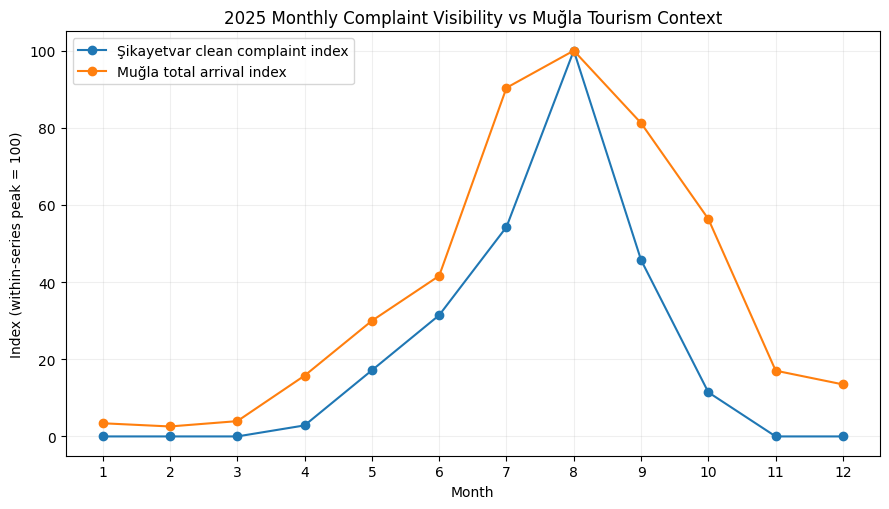

PosixPath('reports/figures/sikayetvar_eda/10_2025_complaints_vs_mugla_tourism.png')

In [28]:
tourism_2025 = tourism_monthly[tourism_monthly["year"] == 2025].copy()
tourism_2025["month"] = pd.to_datetime(tourism_2025["period"]).dt.month
complaints_2025 = pd.DataFrame({"month": np.arange(1, 13)}).merge(
    dated[dated["year"] == 2025].groupby("month").size().rename("complaint_count").reset_index(), on="month", how="left"
).fillna({"complaint_count": 0})
tourism_compare = complaints_2025.merge(tourism_2025[["month", "total_arrivals"]], on="month", how="left")
tourism_compare["complaint_index"] = 100 * tourism_compare["complaint_count"] / tourism_compare["complaint_count"].max()
tourism_compare["mugla_arrival_index"] = 100 * tourism_compare["total_arrivals"] / tourism_compare["total_arrivals"].max()
temporal_tourism_corr = stats.spearmanr(tourism_compare["complaint_count"], tourism_compare["total_arrivals"], nan_policy="omit")
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(tourism_compare["month"], tourism_compare["complaint_index"], marker="o", label="Şikayetvar clean complaint index")
ax.plot(tourism_compare["month"], tourism_compare["mugla_arrival_index"], marker="o", label="Muğla total arrival index")
ax.set_xticks(range(1, 13)); ax.set(title="2025 Monthly Complaint Visibility vs Muğla Tourism Context", xlabel="Month", ylabel="Index (within-series peak = 100)")
ax.grid(alpha=0.2); ax.legend()
save_fig(fig, "10_2025_complaints_vs_mugla_tourism.png")


In [29]:
explain_figure(
    "2025 monthly complaint corpus ile Muğla total arrivals ayrı ayrı peak=100 endeksine çevrilip şekil olarak karşılaştırılır.",
    f"2025 clean dated complaint n={int(tourism_compare['complaint_count'].sum())}; aylık Spearman rho={temporal_tourism_corr.statistic:.3f}, n={int(tourism_compare['total_arrivals'].notna().sum())}.",
    "Complaint görünürlüğünün geniş turizm sezonuyla birlikte hareket edip etmediğine descriptif bağlam verir.",
    "Muğla, Bodrum'dan geniş coğrafyadır; arrival bir complaint denominator'ı değildir. Platform erişimi, complaint delay'i ve approximate dates vardır; nedensellik/trend sonucu çıkarılmaz."
)


### Grafik nasıl okunur?
2025 monthly complaint corpus ile Muğla total arrivals ayrı ayrı peak=100 endeksine çevrilip şekil olarak karşılaştırılır.

### Ne görüyoruz?
2025 clean dated complaint n=92; aylık Spearman rho=0.921, n=12.

### Neden önemli?
Complaint görünürlüğünün geniş turizm sezonuyla birlikte hareket edip etmediğine descriptif bağlam verir.

### Dikkat edilmesi gereken nokta
Muğla, Bodrum'dan geniş coğrafyadır; arrival bir complaint denominator'ı değildir. Platform erişimi, complaint delay'i ve approximate dates vardır; nedensellik/trend sonucu çıkarılmaz.

## 09. Complaint text length

,statistic,value
0,count,229.000000
1,mean,158.091703
2,std,85.376233
3,min,31.000000
4,25%,92.000000
5,50%,144.000000
6,75%,205.000000
7,90%,277.600000
8,95%,307.200000
9,max,623.000000


,hotel_name,matched_complaint_count,median_complaint_word_count,small_n_flag
7,Green Bay Resort & Spa Bodrum,11,198.5,False
10,Salmakis Resort & Spa,7,194.0,False
1,Azure By Yelken Hotel,26,184.5,False
11,Kadıkale Resort,7,175.0,False
13,Sami Beach Hotel,6,172.0,False
0,Kefaluka Resort,29,165.0,False
3,La Blanche Island Bodrum,19,150.0,False
4,Petunya Beach Resort,13,147.0,False
9,Selectum Colours Bodrum,8,140.0,False
12,Ladonia Hotels Zemda,7,137.0,False


,area,matched_complaint_count,median_word_count,coverage_flag
1,Akyarlar,55,159.0,ADEQUATE_EXPLORATORY
4,Ortakent-Yahşi,16,151.5,LOW
2,Güvercinlik,39,151.0,ADEQUATE_EXPLORATORY
5,Bodrum Merkez,13,144.0,LOW
0,Kadıkalesi,56,141.5,ADEQUATE_EXPLORATORY
3,Gümbet,24,140.0,ADEQUATE_EXPLORATORY
8,Gümüşlük,7,137.0,LOW
6,Turgutreis,13,122.0,ADEQUATE_EXPLORATORY
7,Torba,10,72.5,LOW


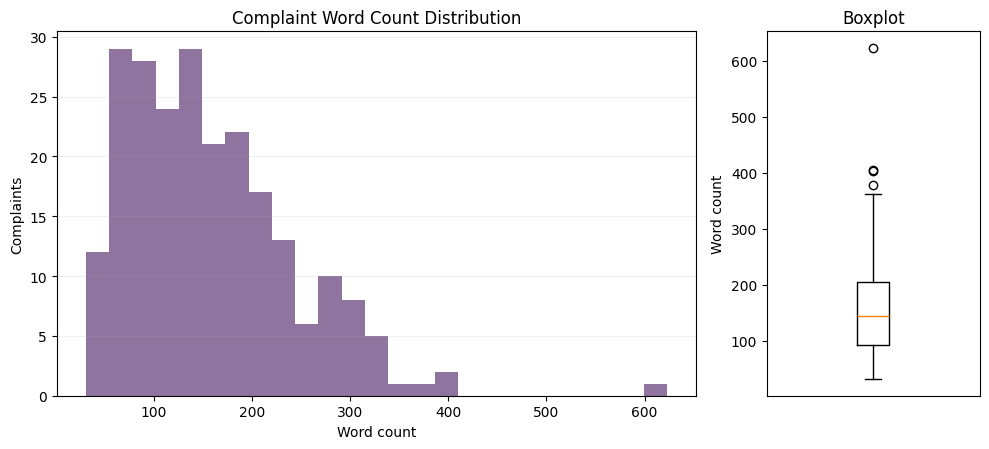

PosixPath('reports/figures/sikayetvar_eda/11_complaint_word_count_distribution.png')

In [30]:
word_values = complaints["complaint_word_count"].dropna()
word_stats = word_values.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).rename("value").reset_index().rename(columns={"index":"statistic"})
display(word_stats)
display(hotel_summary.loc[hotel_summary["matched_complaint_count"].ge(MIN_COMPLAINTS_FOR_RATE_CHART), [
    "hotel_name", "matched_complaint_count", "median_complaint_word_count", "small_n_flag"
]].sort_values("median_complaint_word_count", ascending=False))
display(area_summary.loc[area_summary["matched_complaint_count"].ge(MIN_COMPLAINTS_FOR_RATE_CHART), [
    "area", "matched_complaint_count", "median_word_count", "coverage_flag"
]].sort_values("median_word_count", ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6), gridspec_kw={"width_ratios":[3, 1]})
axes[0].hist(word_values, bins=25, color="#7A5C8E", alpha=0.85)
axes[0].set(title="Complaint Word Count Distribution", xlabel="Word count", ylabel="Complaints")
axes[0].grid(axis="y", alpha=0.2)
axes[1].boxplot(word_values, vert=True, showfliers=True)
axes[1].set(title="Boxplot", ylabel="Word count", xticks=[])
save_fig(fig, "11_complaint_word_count_distribution.png")


In [31]:
explain_figure(
    "Histogram ve boxplot non-missing complaint text'lerin türetilmiş word count dağılımını gösterir.",
    f"Geçerli text n={len(word_values)}; median={word_values.median():.0f}, Q1={word_values.quantile(.25):.0f}, Q3={word_values.quantile(.75):.0f} kelime.",
    "NLP input uzunluğu, token bütçesi ve kısa/uzun metin dengesini planlamaya yardım eder.",
    "7 missing complaint text bu dağılıma girmez; uzunluk içerik kalitesi veya complaint ciddiyeti değildir."
)


### Grafik nasıl okunur?
Histogram ve boxplot non-missing complaint text'lerin türetilmiş word count dağılımını gösterir.

### Ne görüyoruz?
Geçerli text n=229; median=144, Q1=92, Q3=205 kelime.

### Neden önemli?
NLP input uzunluğu, token bütçesi ve kısa/uzun metin dengesini planlamaya yardım eder.

### Dikkat edilmesi gereken nokta
7 missing complaint text bu dağılıma girmez; uzunluk içerik kalitesi veya complaint ciddiyeti değildir.

## 10. View count distribution

,statistic,value
0,count,225.000000
1,mean,1368.604444
2,std,1480.295654
3,min,1.000000
4,25%,232.000000
5,50%,794.000000
6,75%,2078.000000
7,90%,3457.200000
8,95%,4549.000000
9,99%,6235.840000


,complaint_id,hotel_name,area,complaint_date,view_count_numeric,complaint_title
222,jolly-tatil-ile-alinan-yasmin-bodrum-resort-pismanligi-video,Yasmin Bodrum Resort,Kadıkalesi,2024-06-06 16:41:00,6935.0,Jolly Tatil İle Alınan
25,azure-by-yelken-hotel-sikayetciyim,Azure By Yelken Hotel,Kadıkalesi,2024-08-07 12:24:00,6438.0,Şikayetçiyim
219,yasmin-bodrum-resort-otel-deneyimi-degerlendirmesi,Yasmin Bodrum Resort,Kadıkalesi,2024-09-02 15:39:00,6238.0,Otel Deneyimi Değerlendirmesi
26,azure-by-yelken-hotel-azure-by-yelken-odamizin-baska-birine-ayni-anda-satilmasi-ve-magduriyet,Azure By Yelken Hotel,Kadıkalesi,2024-06-06 19:39:00,6229.0,Azure By Yelken Odamızın Başka Birine Aynı Anda Satılması Ve Mağduriyet
132,la-blanche-resort-spa-bodrum-bodrumda-sabah-bir-uyandik-aramizda-kedi-yatiyor-yatakta,La Blanche Resort Bodrum,Turgutreis,2023-10-17 18:40:00,5990.0,Bodrum'da Sabah Bir Uyandık Aramızda Kedi Yatıyor Yatakta!
117,la-blanche-island-bodrum-la-blanche-island-pismanligi,La Blanche Island Bodrum,Güvercinlik,2024-09-30 09:51:00,5820.0,La Blanche Island Pişmanlığı
22,tatilbudurda-hayal-kirikligi-temizlik-hizmet-ve-konfor-sorunlari,Azure By Yelken Hotel,Kadıkalesi,2025-08-01 09:41:00,5279.0,"Tatilbudur'da Hayal Kırıklığı: Temizlik, Hizmet Ve Konfor Sorunları"
218,yasmin-bodrum-resort-bodrumda-tatil-hayal-kirikligi-oda-ve-hizmet-problemleri,Yasmin Bodrum Resort,Kadıkalesi,2024-09-10 10:48:00,4971.0,Bodrum'da Tatil Hayal Kırıklığı: Oda Ve Hizmet Problemleri
118,la-blanche-island-bodrum-tam-bir-hayal-kirikligi-1,La Blanche Island Bodrum,Güvercinlik,2024-09-13 14:40:00,4861.0,Tam Bir Hayal Kırıklığı
223,jolly-tatil-ve-yasmin-bodrum-resort-otel-pismanligi,Yasmin Bodrum Resort,Kadıkalesi,2024-06-05 18:09:00,4705.0,Jolly Tatil Ve


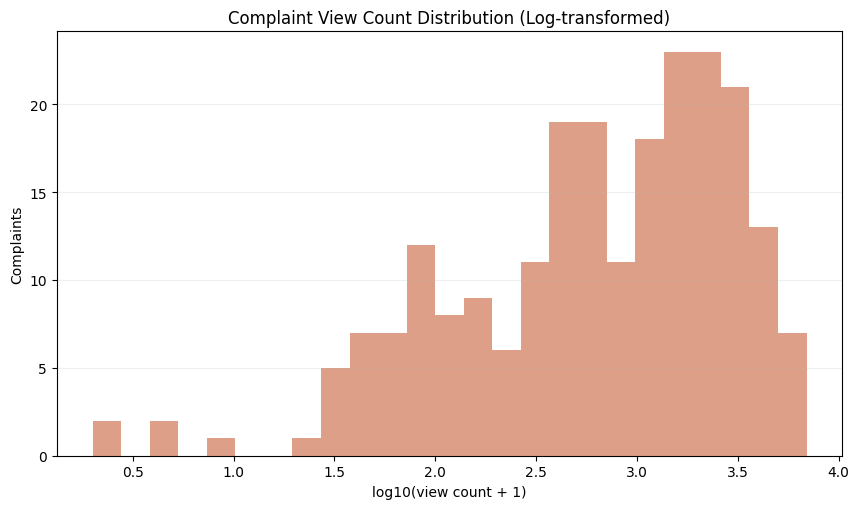

PosixPath('reports/figures/sikayetvar_eda/12_view_count_distribution.png')

In [32]:
view_values = complaints["view_count_numeric"].dropna()
view_stats = view_values.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).rename("value").reset_index().rename(columns={"index":"statistic"})
display(view_stats)
display(complaints.nlargest(10, "view_count_numeric")[["complaint_id", "hotel_name", "area", "complaint_date", "view_count_numeric", "complaint_title"]])
fig, ax = plt.subplots(figsize=(8.7, 5.2))
ax.hist(np.log10(view_values + 1), bins=25, color="#D98E73", alpha=0.85)
ax.set(title="Complaint View Count Distribution (Log-transformed)", xlabel="log10(view count + 1)", ylabel="Complaints")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "12_view_count_distribution.png")


In [33]:
explain_figure(
    "View count sağa çarpık olduğu için x ekseninde log10(view+1) dönüşümüyle dağılım gösterilir; summary table ham sayıları korur.",
    f"View coverage={format_pct_tr(100*len(view_values)/len(complaints))}; median={view_values.median():.0f}, P95={view_values.quantile(.95):.0f}.",
    "Platform içi görünürlüğün tipik seviyesini ve uzun kuyruğunu görünür kılar.",
    "View count zaman içinde birikir; eski complaint'ler daha fazla exposure alabilir. View, unique reader veya etki ölçüsü değildir."
)


### Grafik nasıl okunur?
View count sağa çarpık olduğu için x ekseninde log10(view+1) dönüşümüyle dağılım gösterilir; summary table ham sayıları korur.

### Ne görüyoruz?
View coverage=%95,3; median=794, P95=4549.

### Neden önemli?
Platform içi görünürlüğün tipik seviyesini ve uzun kuyruğunu görünür kılar.

### Dikkat edilmesi gereken nokta
View count zaman içinde birikir; eski complaint'ler daha fazla exposure alabilir. View, unique reader veya etki ölçüsü değildir.

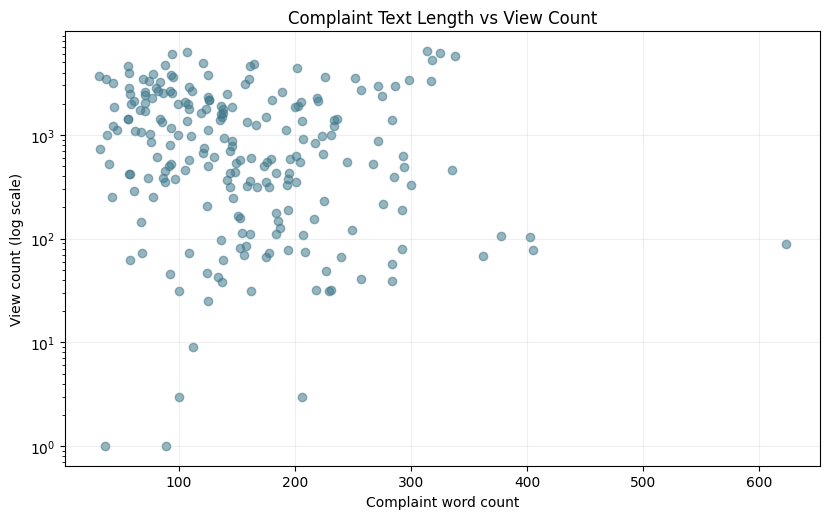

PosixPath('reports/figures/sikayetvar_eda/18_word_count_vs_views.png')

In [34]:
complaint_word_view_pair = complaints[["complaint_word_count", "view_count_numeric", "complaint_date"]].dropna(subset=["complaint_word_count", "view_count_numeric"])
complaint_word_view_corr = stats.spearmanr(complaint_word_view_pair["complaint_word_count"], complaint_word_view_pair["view_count_numeric"])
fig, ax = plt.subplots(figsize=(8.4, 5.3))
ax.scatter(complaint_word_view_pair["complaint_word_count"], complaint_word_view_pair["view_count_numeric"], alpha=.55, color="#40798C")
ax.set_yscale("log")
ax.set(title="Complaint Text Length vs View Count", xlabel="Complaint word count", ylabel="View count (log scale)")
ax.grid(alpha=.2)
save_fig(fig, "18_word_count_vs_views.png")


In [35]:
explain_figure(
    "Her nokta bir clean complaint; x text word count, y platform view count'tur. View ekseni sağa çarpıklık nedeniyle log ölçektedir.",
    f"Spearman rho={complaint_word_view_corr.statistic:.3f}, p={complaint_word_view_corr.pvalue:.4f}, n={len(complaint_word_view_pair)}.",
    "Daha uzun complaint metinlerinin platform görünürlüğüyle birlikte değişip değişmediğini descriptif olarak gösterir.",
    "View zamanla birikir; complaint yaşı, marka görünürlüğü ve platform sıralaması karıştırıcıdır. Nedensellik veya içerik ciddiyeti sonucu çıkarılamaz."
)


### Grafik nasıl okunur?
Her nokta bir clean complaint; x text word count, y platform view count'tur. View ekseni sağa çarpıklık nedeniyle log ölçektedir.

### Ne görüyoruz?
Spearman rho=-0.201, p=0.0029, n=218.

### Neden önemli?
Daha uzun complaint metinlerinin platform görünürlüğüyle birlikte değişip değişmediğini descriptif olarak gösterir.

### Dikkat edilmesi gereken nokta
View zamanla birikir; complaint yaşı, marka görünürlüğü ve platform sıralaması karıştırıcıdır. Nedensellik veya içerik ciddiyeti sonucu çıkarılamaz.

## 11. Company response behavior

,metric,value
0,company_response_count,39.000000
1,no_company_response_count,197.000000
2,company_response_rate_in_corpus_pct,16.525424
3,rate_chart_min_n,5.000000


,response_group,complaint_n,median_word_count,median_view_count,median_company_response_word_count
0,NOT_RESPONDED,197,138.0,876.0,NaN
1,RESPONDED,39,175.0,538.0,190.0


,area,matched_complaint_count,company_response_count,company_response_rate_in_corpus,small_n_flag
0,Kadıkalesi,56,3,5.357143,False
1,Akyarlar,55,31,56.363636,False
2,Güvercinlik,39,5,12.820513,False
3,Gümbet,24,0,0.000000,False
4,Ortakent-Yahşi,16,0,0.000000,False
5,Bodrum Merkez,13,0,0.000000,False
6,Turgutreis,13,0,0.000000,False
7,Torba,10,0,0.000000,False
8,Gümüşlük,7,0,0.000000,False
9,Göltürkbükü,2,0,0.000000,True


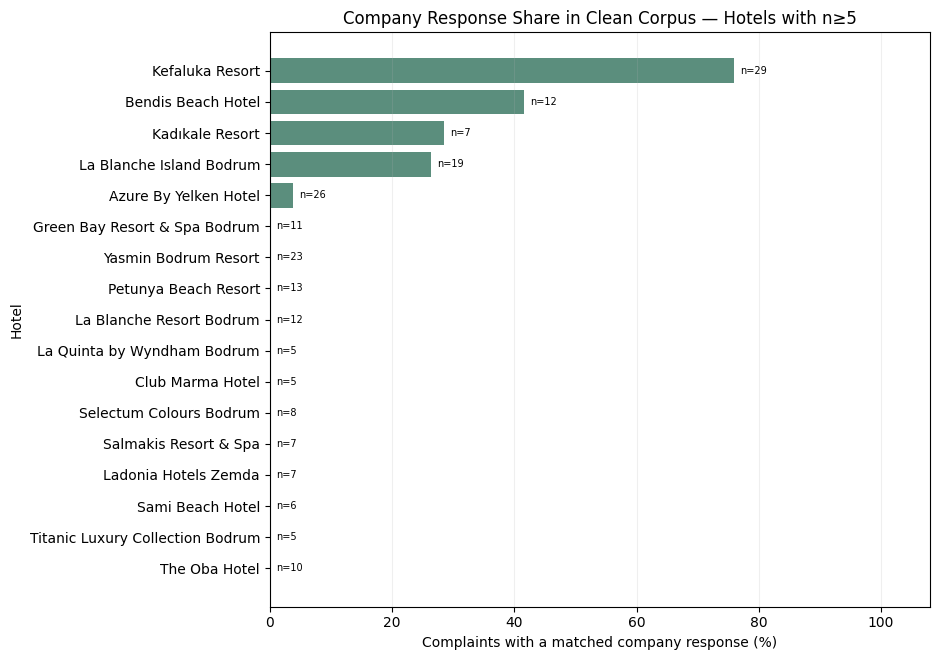

PosixPath('reports/figures/sikayetvar_eda/13_company_response_share_by_hotel.png')

In [36]:
response_overall = pd.DataFrame({
    "metric": ["company_response_count", "no_company_response_count", "company_response_rate_in_corpus_pct", "rate_chart_min_n"],
    "value": [int(complaints["company_response_exists_clean"].sum()), int((~complaints["company_response_exists_clean"]).sum()), 100*complaints["company_response_exists_clean"].mean(), MIN_COMPLAINTS_FOR_RATE_CHART],
})
display(response_overall)
response_group_comparison = complaints.assign(
    response_group=np.where(complaints["company_response_exists_clean"], "RESPONDED", "NOT_RESPONDED")
).groupby("response_group").agg(
    complaint_n=("complaint_id", "size"),
    median_word_count=("complaint_word_count", "median"),
    median_view_count=("view_count_numeric", "median"),
    median_company_response_word_count=("company_response_word_count", "median"),
).reset_index()
display(response_group_comparison)
display(area_summary[["area", "matched_complaint_count", "company_response_count", "company_response_rate_in_corpus", "small_n_flag"]])
response_chart = hotel_summary[hotel_summary["matched_complaint_count"] >= MIN_COMPLAINTS_FOR_RATE_CHART].sort_values("company_response_rate_in_corpus")
fig, ax = plt.subplots(figsize=(9.5, 6.7))
ax.barh(response_chart["hotel_name"], response_chart["company_response_rate_in_corpus"], color="#5B8E7D")
for index, row in enumerate(response_chart.itertuples()):
    ax.text(row.company_response_rate_in_corpus + 1, index, f"n={row.matched_complaint_count}", va="center", fontsize=7)
ax.set(title=f"Company Response Share in Clean Corpus — Hotels with n≥{MIN_COMPLAINTS_FOR_RATE_CHART}", xlabel="Complaints with a matched company response (%)", ylabel="Hotel", xlim=(0, 108))
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "13_company_response_share_by_hotel.png")


In [37]:
explain_figure(
    "Yalnız en az 5 clean complaint'i bulunan hotel'lerde, complaint'lerin kaçında matched company response görüldüğünü gösterir; etiket n'dir.",
    f"Overall clean corpus response count={int(complaints['company_response_exists_clean'].sum())}/{len(complaints)} ({format_pct_tr(100*complaints['company_response_exists_clean'].mean())}).",
    "Platform içinde kurumsal yanıt davranışının coverage-aware karşılaştırmasını sağlar.",
    "Response varlığı çözüm, memnuniyet veya yanıt kalitesi değildir. Küçük örneklem oynaklığı sürer; eşik dışı hotel'ler summary tabloda tutulur."
)


### Grafik nasıl okunur?
Yalnız en az 5 clean complaint'i bulunan hotel'lerde, complaint'lerin kaçında matched company response görüldüğünü gösterir; etiket n'dir.

### Ne görüyoruz?
Overall clean corpus response count=39/236 (%16,5).

### Neden önemli?
Platform içinde kurumsal yanıt davranışının coverage-aware karşılaştırmasını sağlar.

### Dikkat edilmesi gereken nokta
Response varlığı çözüm, memnuniyet veya yanıt kalitesi değildir. Küçük örneklem oynaklığı sürer; eşik dışı hotel'ler summary tabloda tutulur.

## 12. Company response time

,hotel_id,hotel_name,area,complaint_n,response_n,response_date_available_n,median_response_time_days,q25_response_time_days,q75_response_time_days
0,BOD004,Bendis Beach Hotel,Akyarlar,12,5,5.0,0.477083,0.131250,18.560417
1,BOD006,Club Marma Hotel,Akyarlar,5,0,NaN,NaN,NaN,NaN
2,BOD007,Kefaluka Resort,Akyarlar,29,22,21.0,0.689583,0.309722,1.028472
3,BOD010,Mare Garden Hotel,Akyarlar,1,0,NaN,NaN,NaN,NaN
4,BOD012,Selectum Collection Bodrum,Akyarlar,4,0,NaN,NaN,NaN,NaN
5,BOD016,Xanadu Island,Akyarlar,4,4,3.0,9.708333,4.901389,10.387500
6,BOD023,Doria Hotel Bodrum,Bitez,1,0,NaN,NaN,NaN,NaN
7,BOD038,Casa Mare Bodrum,Bodrum Merkez,1,0,NaN,NaN,NaN,NaN
8,BOD041,La Quinta by Wyndham Bodrum,Bodrum Merkez,5,0,NaN,NaN,NaN,NaN
9,BOD045,Salmakis Resort & Spa,Bodrum Merkez,7,0,NaN,NaN,NaN,NaN


,hotel_name,complaint_id,complaint_date,company_response_date_parsed,response_time_days,complaint_date_is_approximate
32,Bendis Beach Hotel,balayi-cifti-olarak-rezervasyonumuz-karsilanmadi-eksik-iade-yapildi,2025-09-19 18:36:00,2026-07-13 09:13:00,296.609028,False
29,Bendis Beach Hotel,sahilde-dus-ve-tuvalet-yok-tekrarlanan-yemekler-ve-kaba-personel,2026-07-20 22:42:00,2026-08-08 12:09:00,18.560417,True
199,Xanadu Island,ultra-her-sey-dahil-otelde-bar-servisi-kabusa-donustu,2026-05-25 12:57:00,2026-06-05 14:33:00,11.066667,True
198,Xanadu Island,ultra-her-sey-dahil-otelde-servis-temizlik-ve-plaj-siparislerinde-surekli-aksakliklar,2026-05-26 21:28:00,2026-06-05 14:28:00,9.708333,True
111,La Blanche Island Bodrum,balayi-ciftine-ozel-hizmetlerde-gecikme-ve-guvenlik-sorunu,2025-09-23 21:48:00,2025-09-30 17:22:00,6.815278,False
110,La Blanche Island Bodrum,la-blanche-island-bodrum-plajda-guvenlik-eksikligi-ve-lakayit-personel-nedeniyle-yasanan-yaralanma,2025-09-28 22:45:00,2025-09-30 17:18:00,1.772917,False
74,Kefaluka Resort,guvenlik-sorunu-ve-aile-saldirisi-nedeniyle-tatil-iptali-ve-ucret-iadesi-talebi,2026-08-21 01:39:00,2026-08-22 20:07:00,1.769444,True
80,Kefaluka Resort,kefaluka-resortta-cokmus-altyapi-ve-yetersiz-yonetim,2026-06-23 18:51:00,2026-06-25 12:02:00,1.715972,True


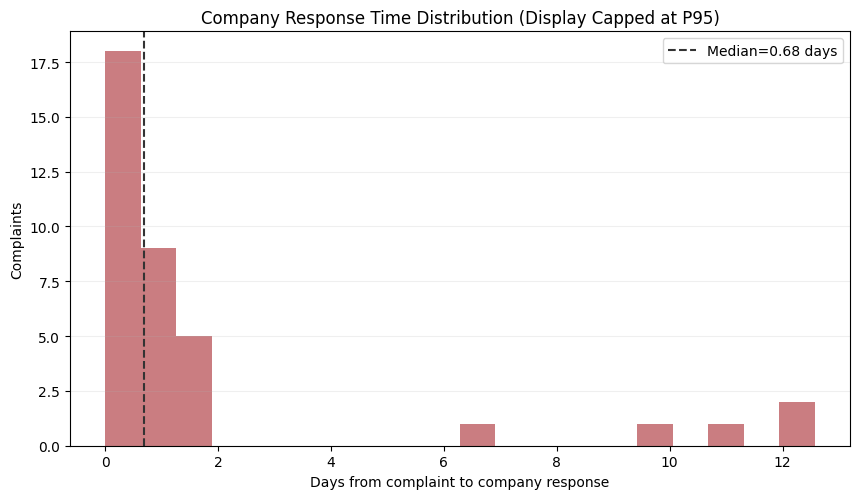

PosixPath('reports/figures/sikayetvar_eda/14_company_response_time_distribution.png')

In [38]:
company_response_time_summary = response_time_summary(complaints)
display(company_response_time_summary)
valid_response_time = complaints.loc[
    complaints["company_response_exists_clean"] & complaints["response_time_days"].notna(), "response_time_days"
]
display(complaints.loc[
    complaints["company_response_exists_clean"] & complaints["response_time_days"].notna(),
    ["hotel_name", "complaint_id", "complaint_date", "company_response_date_parsed", "response_time_days", "complaint_date_is_approximate"],
].nlargest(8, "response_time_days"))
display_q95 = valid_response_time.quantile(.95)
fig, ax = plt.subplots(figsize=(8.7, 5.1))
ax.hist(valid_response_time.clip(upper=display_q95), bins=20, color="#C1666B", alpha=0.85)
ax.axvline(valid_response_time.median(), linestyle="--", color="#333333", label=f"Median={valid_response_time.median():.2f} days")
ax.set(title="Company Response Time Distribution (Display Capped at P95)", xlabel="Days from complaint to company response", ylabel="Complaints")
ax.grid(axis="y", alpha=0.2); ax.legend()
save_fig(fig, "14_company_response_time_distribution.png")


In [39]:
explain_figure(
    "Complaint ve company response tarihleri bulunan, non-negative lag'li kayıtların response time dağılımıdır; okunabilirlik için yalnız grafikte P95 üstü P95'e kırpılır.",
    f"Valid response-time n={len(valid_response_time)}; median={valid_response_time.median():.2f} gün, P75={valid_response_time.quantile(.75):.2f}, max={valid_response_time.max():.2f}. Full değerler summary tabloda korunur.",
    "Tipik yanıt hızını ve sağa çarpık gecikme kuyruğunu gösterir.",
    "Approximate complaint dates vardır; tarih farkı operasyonel SLA değildir. Aykırılar grafikte kırpılmış, tabloda saklanmıştır."
)


### Grafik nasıl okunur?
Complaint ve company response tarihleri bulunan, non-negative lag'li kayıtların response time dağılımıdır; okunabilirlik için yalnız grafikte P95 üstü P95'e kırpılır.

### Ne görüyoruz?
Valid response-time n=37; median=0.68 gün, P75=1.33, max=296.61. Full değerler summary tabloda korunur.

### Neden önemli?
Tipik yanıt hızını ve sağa çarpık gecikme kuyruğunu gösterir.

### Dikkat edilmesi gereken nokta
Approximate complaint dates vardır; tarih farkı operasyonel SLA değildir. Aykırılar grafikte kırpılmış, tabloda saklanmıştır.

## 13. Reply behavior

In [40]:
reply_author_summary = replies.groupby("reply_author_type_clean", dropna=False).size().rename("reply_count").reset_index()
reply_count_dist = complaints["reply_count_total_derived"].value_counts().sort_index().rename_axis("reply_count_per_complaint").reset_index(name="complaint_count")
replied = complaints["reply_count_total_derived"] > 0
reply_behavior_summary = pd.DataFrame({
    "metric": ["clean_reply_count", "complaints_with_any_reply", "complaints_without_reply", "share_with_any_reply_pct", "median_replies_among_replied"],
    "value": [len(replies), int(replied.sum()), int((~replied).sum()), 100*replied.mean(), complaints.loc[replied, "reply_count_total_derived"].median()],
})
display(reply_behavior_summary)
display(reply_author_summary)
reply_group_comparison = complaints.assign(
    reply_group=np.where(replied, "REPLIED", "NOT_REPLIED")
).groupby("reply_group").agg(
    complaint_n=("complaint_id", "size"),
    median_word_count=("complaint_word_count", "median"),
    median_view_count=("view_count_numeric", "median"),
).reset_index()
display(reply_group_comparison)
display(hotel_summary.loc[hotel_summary["matched_complaint_count"].ge(MIN_COMPLAINTS_FOR_RATE_CHART), [
    "hotel_name", "matched_complaint_count", "complaints_with_replies", "total_reply_count", "median_reply_count", "max_reply_count", "reply_coverage_pct"
]].sort_values("total_reply_count", ascending=False))


,metric,value
0,clean_reply_count,97.000000
1,complaints_with_any_reply,62.000000
2,complaints_without_reply,174.000000
3,share_with_any_reply_pct,26.271186
4,median_replies_among_replied,1.000000


,reply_author_type_clean,reply_count
0,COMPANY,41
1,USER,56


,reply_group,complaint_n,median_word_count,median_view_count
0,NOT_REPLIED,174,137.5,1017.0
1,REPLIED,62,166.0,477.0


,hotel_name,matched_complaint_count,complaints_with_replies,total_reply_count,median_reply_count,max_reply_count,reply_coverage_pct
0,Kefaluka Resort,29,23,46,1.0,6,79.310345
3,La Blanche Island Bodrum,19,6,9,0.0,3,31.578947
5,Bendis Beach Hotel,12,6,9,0.5,3,50.000000
11,Kadıkale Resort,7,4,5,1.0,2,57.142857
1,Azure By Yelken Hotel,26,1,3,0.0,3,3.846154
10,Salmakis Resort & Spa,7,1,2,0.0,2,14.285714
4,Petunya Beach Resort,13,2,2,0.0,1,15.384615
12,Ladonia Hotels Zemda,7,2,2,0.0,1,28.571429
7,Green Bay Resort & Spa Bodrum,11,2,2,0.0,1,18.181818
14,Titanic Luxury Collection Bodrum,5,1,1,0.0,1,20.000000


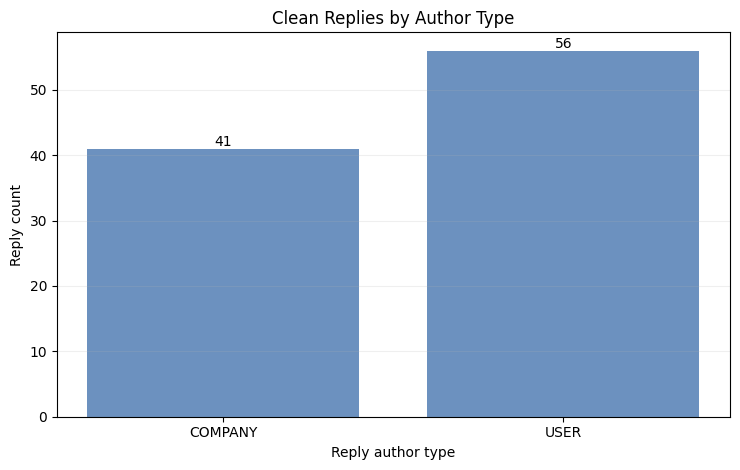

PosixPath('reports/figures/sikayetvar_eda/15_reply_author_distribution.png')

In [41]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(reply_author_summary["reply_author_type_clean"].astype(str), reply_author_summary["reply_count"], color="#6C91BF")
ax.bar_label(bars)
ax.set(title="Clean Replies by Author Type", xlabel="Reply author type", ylabel="Reply count")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "15_reply_author_distribution.png")


In [42]:
explain_figure(
    "Her çubuk clean reply kayıtlarını normalized reply author type'a göre sayar.",
    f"Toplam {len(replies)} clean reply, {int(replied.sum())} complaint'e bağlıdır.",
    "Company/user reply ayrımını ve gelecekteki conversation-level NLP evrenini gösterir.",
    "Reply sayısı çözüm veya interaction kalitesi değildir; clean corpus dışında kalan review-required replies dahil değildir."
)


### Grafik nasıl okunur?
Her çubuk clean reply kayıtlarını normalized reply author type'a göre sayar.

### Ne görüyoruz?
Toplam 97 clean reply, 62 complaint'e bağlıdır.

### Neden önemli?
Company/user reply ayrımını ve gelecekteki conversation-level NLP evrenini gösterir.

### Dikkat edilmesi gereken nokta
Reply sayısı çözüm veya interaction kalitesi değildir; clean corpus dışında kalan review-required replies dahil değildir.

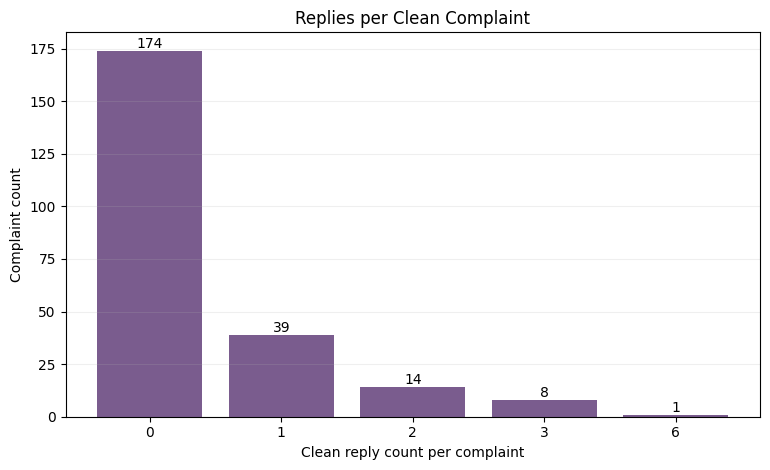

PosixPath('reports/figures/sikayetvar_eda/16_replies_per_complaint.png')

In [43]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
bars = ax.bar(reply_count_dist["reply_count_per_complaint"].astype(str), reply_count_dist["complaint_count"], color="#7A5C8E")
ax.bar_label(bars)
ax.set(title="Replies per Clean Complaint", xlabel="Clean reply count per complaint", ylabel="Complaint count")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "16_replies_per_complaint.png")


In [44]:
explain_figure(
    "Clean complaint'ler kendilerine bağlanan clean reply sayısına göre gruplandırılır; sıfır reply de dahildir.",
    f"Any-reply share={format_pct_tr(100*replied.mean())}; replied complaints içinde median={complaints.loc[replied, 'reply_count_total_derived'].median():.0f} reply.",
    "Thread yoğunluğunu ve conversation-style NLP için mevcut interaction derinliğini gösterir.",
    "Scraper yalnız erişilebilen reply'ları görür; reply count konuşmanın eksiksizliği veya çözüm sonucu değildir."
)


### Grafik nasıl okunur?
Clean complaint'ler kendilerine bağlanan clean reply sayısına göre gruplandırılır; sıfır reply de dahildir.

### Ne görüyoruz?
Any-reply share=%26,3; replied complaints içinde median=1 reply.

### Neden önemli?
Thread yoğunluğunu ve conversation-style NLP için mevcut interaction derinliğini gösterir.

### Dikkat edilmesi gereken nokta
Scraper yalnız erişilebilen reply'ları görür; reply count konuşmanın eksiksizliği veya çözüm sonucu değildir.

## 14. Limited official star, capacity and price context

In [45]:
official_context = hotel_summary[[
    "hotel_name", "matched_complaint_count", "cross_platform_complaint_visibility_per_1000_google_reviews", "official_star_rating_verified",
    "official_room_count", "official_bed_count", "search_price_usd_snapshot",
]].copy()
official_coverage = pd.DataFrame({
    "field": ["official_star_rating_verified", "official_room_count", "search_price_usd_snapshot"],
    "non_missing_hotels": [official_context[c].notna().sum() for c in ["official_star_rating_verified", "official_room_count", "search_price_usd_snapshot"]],
    "hotel_universe": len(official_context),
})
official_coverage["coverage_pct"] = 100*official_coverage["non_missing_hotels"]/official_coverage["hotel_universe"]
display(official_coverage)
display(hotel_summary.groupby("official_star_rating_verified", dropna=False).agg(
    hotel_count=("hotel_id", "size"),
    clean_complaints=("matched_complaint_count", "sum"),
    median_complaints=("matched_complaint_count", "median"),
    median_cross_platform_visibility=("cross_platform_complaint_visibility_per_1000_google_reviews", "median"),
).reset_index())


,field,non_missing_hotels,hotel_universe,coverage_pct
0,official_star_rating_verified,10,32,31.250
1,official_room_count,10,32,31.250
2,search_price_usd_snapshot,25,32,78.125


,official_star_rating_verified,hotel_count,clean_complaints,median_complaints,median_cross_platform_visibility
0,4.0,4,22,4.0,2.311155
1,5.0,6,33,5.0,1.544198
2,NaN,22,181,5.0,3.556941


### Bölüm Sonucu

Official room capacity yalnız 10/32 hotel için bulunduğundan kapasite ilişkileri keşifsel kalır.
Fiyat tek bir source-date snapshot'ıdır ve sezon/oda tipi/paket farklarını temsil etmez. Star/capacity/
price karşılaştırmaları hiçbir biçimde kalite sıralaması olarak kullanılmaz.


## 15. Hotel-level exploratory correlations

In [46]:
correlation_pairs = [
    ("google_review_count", "matched_complaint_count"),
    ("google_rating", "matched_complaint_count"),
    ("google_rating", "cross_platform_complaint_visibility_per_1000_google_reviews"),
    ("official_room_count", "matched_complaint_count"),
    ("official_room_count", "cross_platform_complaint_visibility_per_1000_google_reviews"),
    ("search_price_usd_snapshot", "matched_complaint_count"),
    ("search_price_usd_snapshot", "cross_platform_complaint_visibility_per_1000_google_reviews"),
    ("median_complaint_word_count", "median_view_count"),
    ("matched_complaint_count", "company_response_rate_in_corpus"),
]
hotel_level_correlations = spearman_table(hotel_summary, correlation_pairs)
display(hotel_level_correlations)

complaint_word_view_pair = complaints[["complaint_word_count", "view_count_numeric"]].dropna()
complaint_word_view_corr = stats.spearmanr(complaint_word_view_pair["complaint_word_count"], complaint_word_view_pair["view_count_numeric"])
display(pd.DataFrame([{
    "level":"complaint", "metric_x":"complaint_word_count", "metric_y":"view_count_numeric",
    "n":len(complaint_word_view_pair), "spearman_rho":complaint_word_view_corr.statistic,
    "p_value":complaint_word_view_corr.pvalue,
    "caution":"View accumulates with age; association is exploratory and non-causal."
}]))


,metric_x,metric_y,n,spearman_rho,p_value,interpretation,main_caution
0,google_review_count,matched_complaint_count,32,0.587207,0.000411,"Orta, aynı yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
1,google_rating,matched_complaint_count,32,-0.002885,0.987499,"Çok zayıf, ters yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
2,google_rating,cross_platform_complaint_visibility_per_1000_google_reviews,32,-0.452470,0.009318,"Orta, ters yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
3,official_room_count,matched_complaint_count,10,0.945140,0.000037,"Çok güçlü, aynı yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
4,official_room_count,cross_platform_complaint_visibility_per_1000_google_reviews,10,0.321212,0.365468,"Zayıf, aynı yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
5,search_price_usd_snapshot,matched_complaint_count,25,0.410919,0.041296,"Orta, aynı yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
6,search_price_usd_snapshot,cross_platform_complaint_visibility_per_1000_google_reviews,25,-0.120000,0.567760,"Çok zayıf, ters yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
7,median_complaint_word_count,median_view_count,32,-0.087259,0.634871,"Çok zayıf, ters yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."
8,matched_complaint_count,company_response_rate_in_corpus,32,0.453427,0.009152,"Orta, aynı yönlü sıralı birliktelik.","Exploratory; selected mapped-hotel sample, platform bias, no causality."


,level,metric_x,metric_y,n,spearman_rho,p_value,caution
0,complaint,complaint_word_count,view_count_numeric,218,-0.200598,0.002929,View accumulates with age; association is exploratory and non-causal.


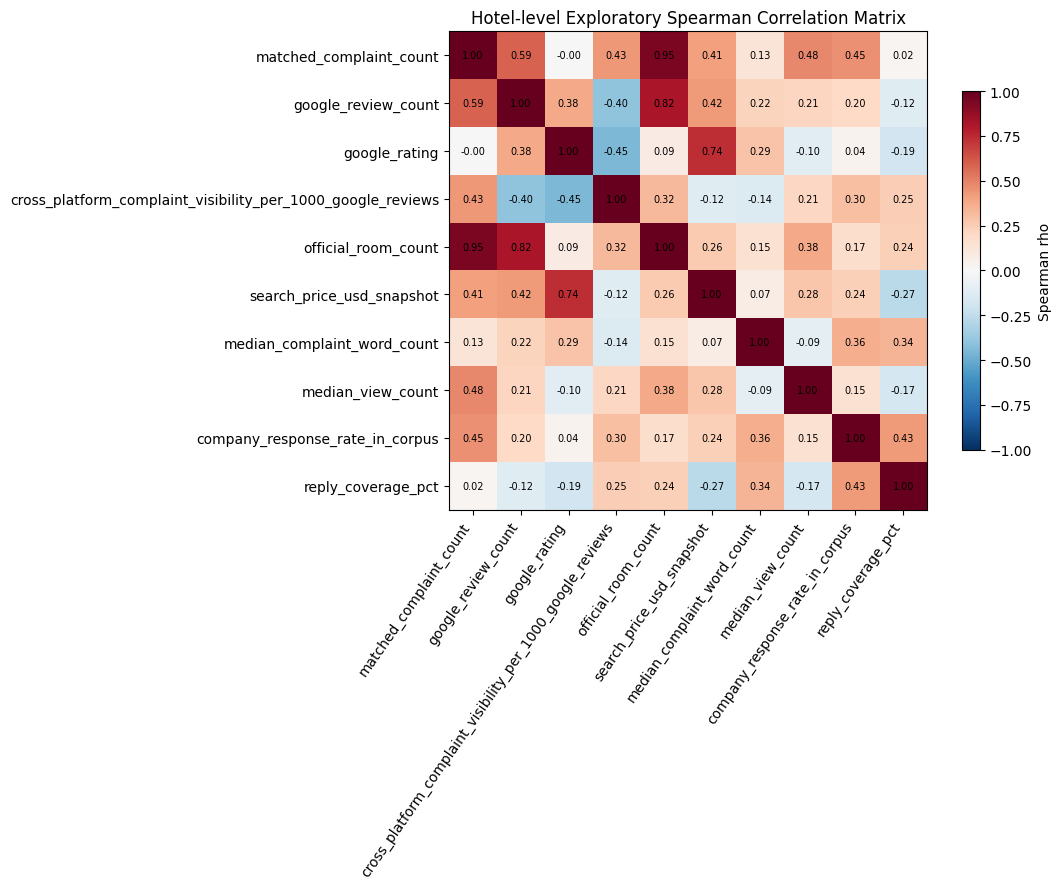

PosixPath('reports/figures/sikayetvar_eda/17_hotel_level_correlation_heatmap.png')

In [47]:
heatmap_columns = [
    "matched_complaint_count", "google_review_count", "google_rating",
    "cross_platform_complaint_visibility_per_1000_google_reviews", "official_room_count",
    "search_price_usd_snapshot", "median_complaint_word_count", "median_view_count",
    "company_response_rate_in_corpus", "reply_coverage_pct",
]
corr_matrix = numeric_correlation_matrix(hotel_summary, heatmap_columns)
fig, ax = plt.subplots(figsize=(11.5, 9.0))
image = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=55, ha="right")
ax.set_yticks(np.arange(len(corr_matrix.index)), labels=corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, "" if pd.isna(value) else f"{value:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=ax, shrink=.75, label="Spearman rho")
ax.set_title("Hotel-level Exploratory Spearman Correlation Matrix")
save_fig(fig, "17_hotel_level_correlation_heatmap.png")


In [48]:
explain_figure(
    "Hücreler hotel-level değişken çiftlerinin Spearman rho değerini gösterir; kırmızı aynı yön, mavi ters yön birlikteliktir.",
    "En dikkat çekici ham ilişki room coverage bulunan küçük alt örneklemde capacity ile complaint count arasındadır; normalized visibility ilişkisi daha zayıftır.",
    "Exposure, kapasite, fiyat, response ve text yapısını tek bir keşifsel haritada karşılaştırır.",
    "Her hücrenin n'i farklı olabilir ve heatmap bunu göstermez; kesin n ve p-value CSV tablosundadır. Official room n çok düşüktür, price snapshot'tır, nedensellik yoktur."
)


### Grafik nasıl okunur?
Hücreler hotel-level değişken çiftlerinin Spearman rho değerini gösterir; kırmızı aynı yön, mavi ters yön birlikteliktir.

### Ne görüyoruz?
En dikkat çekici ham ilişki room coverage bulunan küçük alt örneklemde capacity ile complaint count arasındadır; normalized visibility ilişkisi daha zayıftır.

### Neden önemli?
Exposure, kapasite, fiyat, response ve text yapısını tek bir keşifsel haritada karşılaştırır.

### Dikkat edilmesi gereken nokta
Her hücrenin n'i farklı olabilir ve heatmap bunu göstermez; kesin n ve p-value CSV tablosundadır. Official room n çok düşüktür, price snapshot'tır, nedensellik yoktur.

## 16. Notable cases — investigation queue, not ranking

In [49]:
notable_specs = [
    ("matched_complaint_count", "HIGH_CORPUS_VOLUME", "High clean-corpus visibility; exposure context required", "largest"),
    ("cross_platform_complaint_visibility_per_1000_google_reviews", "HIGH_CROSS_PLATFORM_VISIBILITY", "High cross-platform visibility index; not a complaint rate", "largest"),
    ("median_view_count", "HIGH_MEDIAN_VIEW_MIN_N", "High median view among hotels with complaint n>=5; age confounding", "largest"),
    ("company_response_rate_in_corpus", "LOW_RESPONSE_SHARE_MIN_N", "Low matched-response share among hotels with complaint n>=5; not resolution", "smallest"),
]
notable_records = []
for metric, reason_flag, reason, direction in notable_specs:
    pool = hotel_summary if metric in {"matched_complaint_count", "cross_platform_complaint_visibility_per_1000_google_reviews"} else hotel_summary.loc[hotel_summary["matched_complaint_count"].ge(MIN_COMPLAINTS_FOR_RATE_CHART)]
    selected = pool.nlargest(5, metric) if direction == "largest" else pool.nsmallest(5, metric)
    for row in selected.itertuples():
        notable_records.append({
            "hotel_name": row.hotel_name,
            "area": row.area,
            "metric": metric,
            "value": getattr(row, metric),
            "matched_complaint_count": row.matched_complaint_count,
            "reason_flag": reason_flag,
            "selection_reason": reason,
            "small_n_flag": row.small_n_flag,
            "low_google_review_denominator_flag": row.low_google_review_denominator_flag,
            "caution_note": "Selected mapped corpus; platform visibility and sample size differ; no quality ranking.",
        })
notable_cases = pd.DataFrame(notable_records).sort_values(["reason_flag", "value"], ascending=[True, False])
display(notable_cases)


,hotel_name,area,metric,value,matched_complaint_count,reason_flag,selection_reason,small_n_flag,low_google_review_denominator_flag,caution_note
0,Kefaluka Resort,Akyarlar,matched_complaint_count,29.000000,29,HIGH_CORPUS_VOLUME,High clean-corpus visibility; exposure context required,False,False,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
1,Azure By Yelken Hotel,Kadıkalesi,matched_complaint_count,26.000000,26,HIGH_CORPUS_VOLUME,High clean-corpus visibility; exposure context required,False,True,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
2,Yasmin Bodrum Resort,Kadıkalesi,matched_complaint_count,23.000000,23,HIGH_CORPUS_VOLUME,High clean-corpus visibility; exposure context required,False,False,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
3,La Blanche Island Bodrum,Güvercinlik,matched_complaint_count,19.000000,19,HIGH_CORPUS_VOLUME,High clean-corpus visibility; exposure context required,False,False,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
4,Petunya Beach Resort,Ortakent-Yahşi,matched_complaint_count,13.000000,13,HIGH_CORPUS_VOLUME,High clean-corpus visibility; exposure context required,False,False,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
5,Azure By Yelken Hotel,Kadıkalesi,cross_platform_complaint_visibility_per_1000_google_reviews,46.017699,26,HIGH_CROSS_PLATFORM_VISIBILITY,High cross-platform visibility index; not a complaint rate,False,True,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
6,Ladonia Hotels Zemda,Gümüşlük,cross_platform_complaint_visibility_per_1000_google_reviews,18.617021,7,HIGH_CROSS_PLATFORM_VISIBILITY,High cross-platform visibility index; not a complaint rate,False,True,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
7,The Oba Hotel,Torba,cross_platform_complaint_visibility_per_1000_google_reviews,16.583748,10,HIGH_CROSS_PLATFORM_VISIBILITY,High cross-platform visibility index; not a complaint rate,False,True,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
8,Celeste Bella Luxury Hotel & Spa,Ortakent-Yahşi,cross_platform_complaint_visibility_per_1000_google_reviews,7.751938,2,HIGH_CROSS_PLATFORM_VISIBILITY,High cross-platform visibility index; not a complaint rate,True,True,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.
9,Kefaluka Resort,Akyarlar,cross_platform_complaint_visibility_per_1000_google_reviews,6.755183,29,HIGH_CROSS_PLATFORM_VISIBILITY,High cross-platform visibility index; not a complaint rate,False,False,Selected mapped corpus; platform visibility and sample size differ; no quality ranking.


## 17. What can and cannot be concluded

### Güvenle söylenebilecekler

- Clean corpus 236 canonical-unique complaint, 32 reliably mapped hotel ve 11 represented area içerir.
- Corpus hacmi hotel/area düzeyinde eşit dağılmaz; concentration sayısal olarak raporlanabilir.
- Parse edilen tarih, view, structured response ve clean reply alanlarının mevcut coverage'ı ölçülebilir.
- Hotel-level Google context ve sınırlı official metadata ile yalnız keşifsel sıralı birliktelikler hesaplanabilir.

### Söylenemeyecekler

- Hangi hotel'in “en iyi/en kötü” olduğu veya gerçek complaint rate'i.
- Şikayetvar complaint sayısının toplam müşteri sayısına oranı.
- Company response varlığının complaint'i çözdüğü veya kullanıcıyı memnun ettiği.
- 2023–2026 corpus sayılarının gerçek pazar trendi olduğu.
- Korelasyonların nedensel, platformlar arası doğrudan karşılaştırılabilir veya tüm Bodrum hotel evrenine genellenebilir olduğu.


## 18. NLP sample readiness

In [50]:
nlp_sample_readiness = hotel_summary[[
    "hotel_id", "hotel_name", "area", "matched_complaint_count", "complaints_with_replies",
    "company_response_count", "median_complaint_word_count", "small_n_flag", "nlp_sample_tier",
]].copy()
nlp_sample_readiness["tier_rule"] = np.select(
    [nlp_sample_readiness["matched_complaint_count"].ge(15), nlp_sample_readiness["matched_complaint_count"].ge(5)],
    ["HIGH_SAMPLE: n>=15", "MEDIUM_SAMPLE: 5<=n<15"],
    default="LOW_SAMPLE: n<5",
)
nlp_sample_readiness["recommended_use"] = nlp_sample_readiness["nlp_sample_tier"].map({
    "HIGH_SAMPLE":"Hotel-level topic/aspect exploration with uncertainty reporting",
    "MEDIUM_SAMPLE":"Pooled or area-level analysis; hotel findings only as indicative",
    "LOW_SAMPLE":"Pool into broader corpus; avoid hotel-level inference",
})
nlp_sample_readiness["main_caution"] = "Document count alone does not establish representativeness."
display(nlp_sample_readiness.groupby("nlp_sample_tier").agg(hotel_count=("hotel_id", "size"), complaint_count=("matched_complaint_count", "sum")).reset_index())
display(nlp_sample_readiness)


,nlp_sample_tier,hotel_count,complaint_count
0,HIGH_SAMPLE,4,97
1,LOW_SAMPLE,15,31
2,MEDIUM_SAMPLE,13,108


,hotel_id,hotel_name,area,matched_complaint_count,complaints_with_replies,company_response_count,median_complaint_word_count,small_n_flag,nlp_sample_tier,tier_rule,recommended_use,main_caution
0,BOD007,Kefaluka Resort,Akyarlar,29,23,22,165.0,False,HIGH_SAMPLE,HIGH_SAMPLE: n>=15,Hotel-level topic/aspect exploration with uncertainty reporting,Document count alone does not establish representativeness.
1,BOD112,Azure By Yelken Hotel,Kadıkalesi,26,1,1,184.5,False,HIGH_SAMPLE,HIGH_SAMPLE: n>=15,Hotel-level topic/aspect exploration with uncertainty reporting,Document count alone does not establish representativeness.
2,BOD115,Yasmin Bodrum Resort,Kadıkalesi,23,0,0,107.0,False,HIGH_SAMPLE,HIGH_SAMPLE: n>=15,Hotel-level topic/aspect exploration with uncertainty reporting,Document count alone does not establish representativeness.
3,BOD106,La Blanche Island Bodrum,Güvercinlik,19,6,5,150.0,False,HIGH_SAMPLE,HIGH_SAMPLE: n>=15,Hotel-level topic/aspect exploration with uncertainty reporting,Document count alone does not establish representativeness.
4,BOD130,Petunya Beach Resort,Ortakent-Yahşi,13,2,0,147.0,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.
5,BOD004,Bendis Beach Hotel,Akyarlar,12,6,5,132.0,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.
6,BOD160,La Blanche Resort Bodrum,Turgutreis,12,1,0,120.5,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.
7,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,11,2,0,198.5,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.
8,BOD153,The Oba Hotel,Torba,10,1,0,72.5,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.
9,BOD068,Selectum Colours Bodrum,Gümbet,8,0,0,140.0,False,MEDIUM_SAMPLE,MEDIUM_SAMPLE: 5<=n<15,Pooled or area-level analysis; hotel findings only as indicative,Document count alone does not establish representativeness.


### Topic-modeling suitability

Genel corpus 229 non-missing complaint text ile pooled topic/aspect discovery için yeterli bir başlangıç
evrenidir. Hotel-level topic modelleme yalnız `HIGH_SAMPLE` dört hotelde bile küçük-n belirsizliğiyle
ele alınmalıdır. `MEDIUM_SAMPLE` grubu area/pool yaklaşımına, `LOW_SAMPLE` ise yalnız corpus-wide
modellemeye katılmalıdır. Notebook 14 önce language/boilerplate, minimum document frequency,
rare-topic stability ve human validation kontrolleri uygulamalıdır.


## 19. Key findings

In [51]:
top5_names = ", ".join(hotel_summary.head(5)["hotel_name"])
top_visibility_names = ", ".join(hotel_summary.nlargest(5, "cross_platform_complaint_visibility_per_1000_google_reviews")["hotel_name"])
tier_counts = nlp_sample_readiness["nlp_sample_tier"].value_counts()
key_findings = [
    f"Clean EDA corpus: {len(complaints)} canonical-unique complaint, {complaints['hotel_id'].nunique()} hotel, {complaints['area'].nunique()} represented area.",
    f"Top-5 corpus-volume hotels: {top5_names}.",
    f"Top-3 / Top-5 / Top-10 complaint corpus shares: {concentration['top3_hotel_complaint_share_pct']:.1f}% / {concentration['top5_hotel_complaint_share_pct']:.1f}% / {concentration['top10_hotel_complaint_share_pct']:.1f}%.",
    f"{int(concentration['hotels_to_reach_80pct'])} hotels account for 80% of the clean complaint corpus; HHI={concentration['hhi_hotel_complaint_concentration']:.3f}.",
    f"Highest area corpus volume is {area_summary.iloc[0]['area']} with {int(area_summary.iloc[0]['matched_complaint_count'])} complaints; area results must be read with mapping coverage (rho={area_cov_corr.statistic:.3f}, n={len(area_summary)}).",
    f"Google review count vs clean complaint count: Spearman rho={google_corr.statistic:.3f}, n={len(google_pair)}; raw volume requires visibility context.",
    f"Google rating vs cross-platform visibility index: rho={visibility_corr.statistic:.3f}, n={len(visibility_pair)}; index is not a real complaint rate.",
    f"Highest cross-platform visibility candidates: {top_visibility_names}; low Google denominators and small complaint n are flagged.",
    f"Date coverage: {100*len(dated)/len(complaints):.1f}%; observed {dated['complaint_date'].min().date()} to {dated['complaint_date'].max().date()}, with {int(complaints['complaint_date_is_approximate'].sum())} approximate dates.",
    f"Complaint text coverage: {len(word_values)}/{len(complaints)}; median {word_values.median():.0f} words (Q1 {word_values.quantile(.25):.0f}, Q3 {word_values.quantile(.75):.0f}).",
    f"View coverage: {len(view_values)}/{len(complaints)}; median {view_values.median():.0f}; views accumulate with age.",
    f"Matched company response observed for {int(complaints['company_response_exists_clean'].sum())}/{len(complaints)} complaints ({100*complaints['company_response_exists_clean'].mean():.1f}%); response does not imply resolution.",
    f"Among hotels with n>={MIN_COMPLAINTS_FOR_RATE_CHART}, matched-response shares span {response_chart['company_response_rate_in_corpus'].min():.1f}% to {response_chart['company_response_rate_in_corpus'].max():.1f}%; this is behavior, not outcome quality.",
    f"Valid response lag n={len(valid_response_time)}; median {valid_response_time.median():.2f} days, P75 {valid_response_time.quantile(.75):.2f}, max {valid_response_time.max():.2f}; approximate dates limit precision.",
    f"Clean replies: {len(replies)} across {int(replied.sum())} complaints; any-reply share {100*replied.mean():.1f}%.",
    f"Official room coverage: {int(hotel_summary['official_room_count'].notna().sum())}/{len(hotel_summary)} hotels; capacity correlations are highly exploratory.",
    f"NLP readiness: HIGH={int(tier_counts.get('HIGH_SAMPLE', 0))}, MEDIUM={int(tier_counts.get('MEDIUM_SAMPLE', 0))}, LOW={int(tier_counts.get('LOW_SAMPLE', 0))} hotels; low samples should be pooled.",
    "Notebook 14 should prioritize pooled aspect mentions, sufficient-N hotel/area contrasts, distinctive terms and company response by aspect with human validation.",
]
for finding in key_findings:
    print("-", finding)


- Clean EDA corpus: 236 canonical-unique complaint, 32 hotel, 11 represented area.
- Top-5 corpus-volume hotels: Kefaluka Resort, Azure By Yelken Hotel, Yasmin Bodrum Resort, La Blanche Island Bodrum, Petunya Beach Resort.
- Top-3 / Top-5 / Top-10 complaint corpus shares: 33.1% / 46.6% / 69.1%.
- 14 hotels account for 80% of the clean complaint corpus; HHI=0.063.
- Highest area corpus volume is Kadıkalesi with 56 complaints; area results must be read with mapping coverage (rho=0.841, n=14).
- Google review count vs clean complaint count: Spearman rho=0.587, n=32; raw volume requires visibility context.
- Google rating vs cross-platform visibility index: rho=-0.452, n=32; index is not a real complaint rate.
- Highest cross-platform visibility candidates: Azure By Yelken Hotel, Ladonia Hotels Zemda, The Oba Hotel, Celeste Bella Luxury Hotel & Spa, Kefaluka Resort; low Google denominators and small complaint n are flagged.
- Date coverage: 95.8%; observed 2023-08-28 to 2026-08-24, with 86

## 20. Limitations

In [52]:
limitations = [
    "Şikayetvar is a self-selected negative-customer-voice platform; the corpus is not representative of all stays.",
    "Complaint count is corpus volume, not hotel quality and not a true complaint rate.",
    "Only reliably mapped complaint-level records are included: 32 of 192 project hotels and 11 of 14 areas have clean complaints.",
    "Mapping statuses and platform accessibility are uneven; zero complaints may mean no trusted mapping or no accessible data.",
    "Google Reviews and Şikayetvar use different populations, time windows, prompts and behaviors.",
    "Complaints per 1,000 Google reviews is a cross-platform visibility index, not a statistically valid rate.",
    "2023 and 2026 are partial/accessibility-limited; yearly differences cannot establish trends.",
    "86 complaint dates are approximate and 10 are missing/unparsed, limiting daily response-time precision.",
    "View count accumulates over time and is not a unique-reader or impact measure.",
    "Company response existence does not mean resolution, response quality or customer satisfaction.",
    "Official room/star metadata coverage is limited; price is a single search snapshot.",
    "All correlations are exploratory, sample sizes vary, multiple testing is unadjusted and causality is not supported.",
    "Small-n hotel-level medians and rates are unstable even when the n>=5 display threshold is met.",
    "Seven missing complaint texts are excluded from text-length and future NLP content analyses.",
]
for item in limitations:
    print("-", item)


- Şikayetvar is a self-selected negative-customer-voice platform; the corpus is not representative of all stays.
- Complaint count is corpus volume, not hotel quality and not a true complaint rate.
- Only reliably mapped complaint-level records are included: 32 of 192 project hotels and 11 of 14 areas have clean complaints.
- Mapping statuses and platform accessibility are uneven; zero complaints may mean no trusted mapping or no accessible data.
- Google Reviews and Şikayetvar use different populations, time windows, prompts and behaviors.
- Complaints per 1,000 Google reviews is a cross-platform visibility index, not a statistically valid rate.
- 2023 and 2026 are partial/accessibility-limited; yearly differences cannot establish trends.
- 86 complaint dates are approximate and 10 are missing/unparsed, limiting daily response-time precision.
- View count accumulates over time and is not a unique-reader or impact measure.
- Company response existence does not mean resolution, response

## 21. Exports, validation and Notebook 14 handoff

In [53]:
output_paths = {
    "hotel_summary": REPORTS_DIR / "sikayetvar_hotel_eda_summary.csv",
    "area_summary": REPORTS_DIR / "sikayetvar_area_eda_summary.csv",
    "response_time": REPORTS_DIR / "sikayetvar_company_response_time_summary.csv",
    "correlations": REPORTS_DIR / "sikayetvar_hotel_level_correlations.csv",
    "notable_cases": REPORTS_DIR / "sikayetvar_eda_notable_cases.csv",
    "key_findings": REPORTS_DIR / "sikayetvar_eda_key_findings.txt",
    "limitations": REPORTS_DIR / "sikayetvar_eda_limitations.txt",
    "temporal": REPORTS_DIR / "sikayetvar_temporal_summary.csv",
    "cross_platform": REPORTS_DIR / "sikayetvar_cross_platform_visibility.csv",
    "reply_behavior": REPORTS_DIR / "sikayetvar_reply_behavior_summary.csv",
    "nlp_readiness": REPORTS_DIR / "sikayetvar_nlp_sample_readiness.csv",
}

hotel_summary.to_csv(output_paths["hotel_summary"], index=False)
area_summary.to_csv(output_paths["area_summary"], index=False)
company_response_time_summary.to_csv(output_paths["response_time"], index=False)
hotel_level_correlations.to_csv(output_paths["correlations"], index=False)
notable_cases.to_csv(output_paths["notable_cases"], index=False)
temporal_summary.to_csv(output_paths["temporal"], index=False)
cross_platform_summary.to_csv(output_paths["cross_platform"], index=False)
reply_behavior_summary.to_csv(output_paths["reply_behavior"], index=False)
nlp_sample_readiness.to_csv(output_paths["nlp_readiness"], index=False)
output_paths["key_findings"].write_text("\n".join(f"- {item}" for item in key_findings) + "\n", encoding="utf-8")
output_paths["limitations"].write_text("\n".join(f"- {item}" for item in limitations) + "\n", encoding="utf-8")

clean_hashes_after = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in protected_clean_paths}
figure_paths = sorted(FIGURES_DIR.glob("*.png"))
expected_figures = [f"{index:02d}_" for index in range(1, 19)]
validation_checks = [
    ("clean_complaint_hashes_unchanged", clean_hashes_before == clean_hashes_after, "Notebook 12 clean files remain immutable"),
    ("hotel_aggregation_reconciles", int(hotel_summary["matched_complaint_count"].sum()) == len(complaints), "Hotel counts sum to corpus"),
    ("area_aggregation_reconciles", int(area_summary["matched_complaint_count"].sum()) == len(complaints), "Area counts sum to corpus"),
    ("response_count_reconciles", int(hotel_summary["company_response_count"].sum()) == int(complaints["company_response_exists_clean"].sum()), "Response counts reconcile"),
    ("cross_platform_denominators_positive", hotel_summary.loc[hotel_summary["cross_platform_complaint_visibility_per_1000_google_reviews"].notna(), "google_review_count"].gt(0).all(), "No invalid denominator"),
    ("no_infinite_visibility_ratios", np.isfinite(hotel_summary["cross_platform_complaint_visibility_per_1000_google_reviews"].dropna()).all(), "Ratios are finite"),
    ("all_18_figures_present", len(figure_paths) == 18 and all(any(path.name.startswith(prefix) for path in figure_paths) for prefix in expected_figures), "Expected chart inventory"),
    ("mandatory_outputs_present", all(path.exists() for path in output_paths.values()), "All required/recommended reports exist"),
]
output_validation = pd.DataFrame(validation_checks, columns=["check", "passed", "detail"])
output_validation.to_csv(REPORTS_DIR / "sikayetvar_eda_output_validation.csv", index=False)
assert output_validation["passed"].all(), output_validation.loc[~output_validation["passed"]].to_dict("records")
display(output_validation)
display(pd.DataFrame({"output": list(output_paths), "path": [str(path.relative_to(PROJECT_ROOT)) for path in output_paths.values()]}))
print(f"Validated {len(figure_paths)} figures. Notebook 12 clean data hashes unchanged.")


,check,passed,detail
0,clean_complaint_hashes_unchanged,True,Notebook 12 clean files remain immutable
1,hotel_aggregation_reconciles,True,Hotel counts sum to corpus
2,area_aggregation_reconciles,True,Area counts sum to corpus
3,response_count_reconciles,True,Response counts reconcile
4,cross_platform_denominators_positive,True,No invalid denominator
5,no_infinite_visibility_ratios,True,Ratios are finite
6,all_18_figures_present,True,Expected chart inventory
7,mandatory_outputs_present,True,All required/recommended reports exist


,output,path
0,hotel_summary,reports/sikayetvar_hotel_eda_summary.csv
1,area_summary,reports/sikayetvar_area_eda_summary.csv
2,response_time,reports/sikayetvar_company_response_time_summary.csv
3,correlations,reports/sikayetvar_hotel_level_correlations.csv
4,notable_cases,reports/sikayetvar_eda_notable_cases.csv
5,key_findings,reports/sikayetvar_eda_key_findings.txt
6,limitations,reports/sikayetvar_eda_limitations.txt
7,temporal,reports/sikayetvar_temporal_summary.csv
8,cross_platform,reports/sikayetvar_cross_platform_visibility.csv
9,reply_behavior,reports/sikayetvar_reply_behavior_summary.csv


Validated 18 figures. Notebook 12 clean data hashes unchanged.


### Notebook 14 readiness decision

**Hazır, koşullu.** Pooled NLP analysis 229 non-missing texts üzerinde ilerleyebilir. Hotel-level
sonuçlar yalnız sample tier ve uncertainty ile raporlanmalı; LOW_SAMPLE hotel'ler pool edilmelidir.
Notebook 14 sentiment/aspect/topic aşamasına geçmeden önce Turkish text normalization,
boilerplate/PII-safe processing, rare-topic stability ve human-label validation tasarımını sabitlemelidir.
